In [ ]:
from IPython.display import display, HTML

display(HTML('<div style="font-size:5em; font-weight:bold; text-align:center;">Learning to Reweight Examples <br> for Robust Deep Learning</div>'))


## Make sure to instal the following:  
Installation Commands for macOS \
\ ---------------------------------------   \ 
   \
conda create -n ds-env python=3.10  \
conda activate ds-env

conda install -c conda-forge \
pandas \
numpy \
matplotlib \
seaborn \
scikit-learn \
jupyter \
torchvision \
tqdm \
xgboost \
xlrd

pip install category_encoders  \
\ ---------------------------------------   \ 


# Setup: import and parameters

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
import matplotlib.pyplot as plt
from tqdm import tqdm
import IPython
import gc
import matplotlib
matplotlib.rcParams.update({'errorbar.capsize': 5})

%matplotlib inline
%load_ext autoreload
%autoreload 2

!pip install category_encoders
from category_encoders import woe
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
def set_stantard_experiment_parameters(): # not really used any longuer but can be used to setup initial standard parameters

  data_set = 'Kaggle_Telco_Customer_Churn'   # Kaggle_Telco_Customer_Churn, tv_subscription_churn, kdd98, Kaggle_Credit_Card_Fraud and others (see below)
  print_details = True
  hyperparameters = {
      'lr' : 1e-3,
      'momentum' : 0.9,
      'batch_size' : 256,
      'num_iterations' : 10000,
      'weight_decay': 1e-5
  }
  # Ratio
  testingRatio = 0.1
  validationRatio = 0.1


# Adding Noise to the training data

In [ ]:
import torch
import random

def add_label_noise(data_loader, training_noise):
    """
    Flips the labels of a proportion of the training data.
    """
    
    print("training_noise in add_label_noise:",training_noise)
    if not (0 <= training_noise <= 1):
        raise ValueError("training_noise must be between 0 and 1.")

    all_features = []
    all_labels = []

    # Collecting all data into memory
    for feature_batch, label_batch in data_loader:
        all_features.append(feature_batch)
        all_labels.append(label_batch)

    features = torch.cat(all_features)
    labels = torch.cat(all_labels)

    # Computing how many labels to flip
    total_samples = labels.size(0)
    num_noisy = int(training_noise * total_samples)

    # Randomly choosing indices to flip
    indices_to_flip = random.sample(range(total_samples), num_noisy)

    # Flipping binary labels (0 ↔ 1)
    labels[indices_to_flip] = 1 - labels[indices_to_flip]

    return list(zip(features, labels))

In [ ]:
import torch
import random

def add_label_noise_with_cost(data_loader, training_noise):
    """
    Flips the labels of a proportion of the training data, preserving cost matrices.
    """

    print("training_noise in add_label_noise_with_cost:",training_noise)

    if not (0 <= training_noise <= 1):
        raise ValueError("training_noise must be between 0 and 1.")

    all_features = []
    all_labels = []
    all_costs = []

    # Collecting all data into memory
    for feature_batch, label_batch, cost_batch in data_loader:
        all_features.append(feature_batch)
        all_labels.append(label_batch)
        all_costs.append(cost_batch)

    features = torch.cat(all_features)
    labels = torch.cat(all_labels)
    costs = torch.cat(all_costs)

    # Computing how many labels to flip
    total_samples = labels.size(0)
    num_noisy = int(training_noise * total_samples)

    # Randomly choosing indices to flip
    indices_to_flip = random.sample(range(total_samples), num_noisy)

    # Flipping binary labels (0 ↔ 1)
    labels[indices_to_flip] = 1 - labels[indices_to_flip]

    return list(zip(features, labels, costs))


In [ ]:
def get_noisy_dataloader(data_loader, training_noise):
  noisy_data = add_label_noise(data_loader, training_noise)
  features, labels = zip(*noisy_data)
  dataset = TensorDataset(torch.stack(features), torch.tensor(labels))
  noisy_loader = DataLoader(dataset, batch_size=hyperparameters['batch_size'], shuffle=True)

  return noisy_loader

def get_noisy_dataloader_with_cost(data_loader, training_noise):

    noisy_data = add_label_noise_with_cost(data_loader, training_noise)
    features, labels, costs = zip(*noisy_data)

    dataset = TensorDataset(
        torch.stack(features),
        torch.tensor(labels),
        torch.stack(costs)
    )

    noisy_loader = DataLoader(dataset, batch_size=hyperparameters['batch_size'], shuffle=True)

    return noisy_loader


# Dataset

Most of the code for the preprocessing is either inspired or taken directly from: 
Vanderschueren,T.,Verdonck,T.,Baesens,B.,&Verbeke,W. (2022). Predict-then-optimizeorpredict-
and-optimize? an empirical evaluation of cost-sensitive learning strategies. Information Sci-
ences, 594, 400-415. Retrievedfrom https://www.sciencedirect.com/science/article/pii/
S0020025522001542 doi: 

Github link: https://github.com/toonvds/CostSensitiveLearning 

### Functions for preprocessing

In [ ]:
### Functions for preprocessing ###

# Calculate monthly payment (given credit line cl_i, interest rate int_ and number of terms n_term)
def calculate_a(cl_i, int_, n_term):
    """ Private function """
    return cl_i * ((int_ * (1 + int_) ** n_term) / ((1 + int_) ** n_term - 1))


# Calculate present value (of amount a given interest rate int_ and n_term number of terms)
def calculate_pv(a, int_, n_term):
    """ Private function """
    return a / int_ * (1 - 1 / (1 + int_) ** n_term)


# Calculate credit line Cl
def calculate_cl(k, inc_i, cl_max, debt_i, int_r, n_term):
    """ Private function """
    cl_k = k * inc_i  # k times monthly income
    A = calculate_a(cl_k, int_r, n_term)
    Cl_debt = calculate_pv(inc_i * min(A / inc_i, 1 - debt_i), int_r, n_term)
    return min(cl_k, cl_max, Cl_debt)


# Calculate cost of FN
def calculate_cost_fn(cl_i, lgd):
    return cl_i * lgd


# Calculate cost of FP
def calculate_cost_fp(cl_i, int_r, n_term, int_cf, pi_1, lgd, cl_avg):
    # Lost profit
    a = calculate_a(cl_i, int_r, n_term)
    pv = calculate_pv(a, int_cf, n_term)
    r = pv - cl_i

    # Profit of average customer
    r_avg = calculate_pv(calculate_a(cl_avg, int_r, n_term), int_cf, n_term) - cl_avg
    cost_fp = r - (1 - pi_1) * r_avg + pi_1 * calculate_cost_fn(cl_avg, lgd)
    return max(0, cost_fp)


# Apply functions to arrays
v_calculate_cost_fp = np.vectorize(calculate_cost_fp)
v_calculate_cost_fn = np.vectorize(calculate_cost_fn)
v_calculate_cl = np.vectorize(calculate_cl)

# Set variables/assumptions
k = 3
int_r = 0.0479 / 12
n_term = 24
int_cf = 0.0294 / 12
lgd = .75
cl_max = 25000



### Telco_customer_churn

In [ ]:
def preprocess_telco_customer_churn(eda=False):
    try:
        telco_churn = pd.read_csv('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/Kaggle_Telco_Customer_Churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

    except FileNotFoundError:
        telco_churn = pd.read_csv('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/Kaggle_Telco_Customer_Churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

    # Drop customer ID
    telco_churn = telco_churn.drop('customerID', axis=1)

    # Drop observations with missing values
    telco_churn = telco_churn.replace('', np.nan)
    telco_churn = telco_churn.replace(' ', np.nan)
    telco_churn = telco_churn.dropna()

    # Get labels
    labels = (telco_churn['Churn'] == 'Yes').astype(int)
    telco_churn = telco_churn.drop('Churn', axis=1)

    # EDA
    if eda:
        for key in telco_churn.keys():
            plt.figure(key)
            plt.title(key)
            if not (key == 'TotalCharges'):
                markers, counts = np.unique(telco_churn[key], return_counts=True)
                plt.hist(markers, weights=counts)
            else:
                sns.kdeplot(telco_churn[key].astype(float))
            plt.show()

    # Convert categorical variables
    categorical_variables = [
        # 2 categories:
        'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'PaperlessBilling',
        # 3 or more categories:
        'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
        'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

    # Create the cost matrix based on Monthly Costs (Petrides and Verbeke, 2020)
    amounts = telco_churn['MonthlyCharges'].to_numpy()


    n_samples = amounts.shape[0]
    # print("\n\n ------------- n_samples in preprocess_telco_customer_churn: ")
    # print(n_samples)
    cost_matrix = np.zeros((n_samples, 2, 2))  # cost_matrix [[TN, FN], [FP, TP]]
    cost_matrix[:, 0, 0] = 0.0
    cost_matrix[:, 0, 1] = 12 * amounts
    cost_matrix[:, 1, 0] = 2 * amounts
    cost_matrix[:, 1, 1] = 0

    # covariates = telco_churn.to_numpy()
    covariates = telco_churn
    labels = labels

    print("------ Kaggle_Telco_Customer_Churn correctly loaded ------ \n")
    if print_details:
      print("\n------ Data format loaded -  Kaggle_Telco_Customer_Churn ------ \n")
      print("X_data:",type(X_data))
      print("Y_data:",type(Y_data))
      print("amounts:",type(amounts))
      print("cost_matrix:",type(cost_matrix))
      print("categorical_variables:",type(categorical_variables))
      print("-------------------------------------------------- \n \n")

      # Info on cost_matrix
      print("Type:", type(cost_matrix))
      print("Shape:", cost_matrix.shape)
      print("Data type:", cost_matrix.dtype)
      print("Total size (elements):", cost_matrix.size)
      print("Memory size (bytes):", cost_matrix.nbytes)

      print("X shape:", X_data.shape)
      print("Y shape:", Y_data.shape)
      print("cost_matrix shape:", np.shape(cost_matrix))

      df = df.drop('MonthlyCharges', axis=1)

    return covariates, labels, amounts, cost_matrix, categorical_variables

### Tv_subscription_churn

In [ ]:
def preprocess_tv_subscription_churn(eda=False):
    try:
        df = pd.read_csv('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/preprocess_tv_subscription_churn/churn_tv_subscriptions.csv.gz', delimiter=',', compression='gzip')
    except FileNotFoundError:
        df = pd.read_csv('../data/TV Subscription Churn/churn_tv_subscriptions.csv.gz', delimiter=',',
                         compression='gzip')

    # Drop ID
    df = df.drop('id', axis=1)

    # Get labels
    #labels = df['target'].to_numpy()
    labels = df['target']
    df = df.drop('target', axis=1)

    if eda:
        for key in df.keys():
            plt.figure(key)
            plt.title(key)
            markers, counts = np.unique(df[key], return_counts=True)
            plt.hist(markers, weights=counts)
            plt.show()

    # List categorical variables (none here)
    categorical_variables = []

    # Extract the cost matrix - based on Bahnsen et al. 2015
    n_samples = labels.shape[0]
    cost_matrix = np.zeros((n_samples, 2, 2))  # cost_matrix [[TN, FN], [FP, TP]]
    cost_matrix[:, 0, 0] = df['C_TN']
    cost_matrix[:, 0, 1] = df['C_FN']
    cost_matrix[:, 1, 0] = df['C_FP']
    cost_matrix[:, 1, 1] = df['C_TP']

    clv = df['C_FN']

    df = df.drop(['C_TN', 'C_FN', 'C_FP', 'C_TP'], axis=1)

    # print("------ tv_subscription_churn correctly loaded ------ \n")
    # print("X shape:", X_data.shape)
    # print("Y shape:", Y_data.shape)
    # print("cost_matrix shape:", np.shape(cost_matrix))

    return df, labels, clv, cost_matrix, categorical_variables


### UCI Default of Credit Card Clients

In [ ]:
def preprocess_default_credit_card(eda=False):
    try:
        df = pd.read_excel('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/UCI Default of Credit Card Clients/default of credit card clients.xls', skiprows=[0])
    except FileNotFoundError:
        df = pd.read_excel('../data/UCI Default of Credit Card Clients/default of credit card clients.xls',skiprows=[0])

    # Drop id
    df = df.drop('ID', axis=1)

    # Get labels
    labels = df['default payment next month'].to_numpy()
    df = df.drop('default payment next month', axis=1)

    # EDA
    if eda:
        for key in df.keys():
            plt.figure(key)
            plt.title(key)
            markers, counts = np.unique(df[key], return_counts=True)
            plt.hist(markers, weights=counts)
            plt.show()

    # List categorical variables
    categorical_variables = ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']

    # Create the cost matrix based on Bahnsen  # Todo: ref
    credit_lines = df['LIMIT_BAL'].to_numpy()
    pi_1 = labels.mean()

    n_samples = credit_lines.shape[0]
    cost_matrix = np.zeros((n_samples, 2, 2))  # cost_matrix [[TN, FN], [FP, TP]]
    cost_matrix[:, 0, 0] = 0.0
    cost_matrix[:, 0, 1] = v_calculate_cost_fn(credit_lines, lgd)
    cost_matrix[:, 1, 0] = v_calculate_cost_fp(credit_lines, int_r, n_term, int_cf, pi_1, lgd, credit_lines.mean())
    cost_matrix[:, 1, 1] = 0.0


    #df = df.drop('LIMIT_BAL', axis=1)
    df = pd.DataFrame(df)
    labels = pd.DataFrame(labels).squeeze()
    #credit_lines = pd.DataFrame(credit_lines)
    #cost_matrix = pd.DataFrame(cost_matrix)
    #categorical_variables = pd.DataFrame(categorical_variables)

    print("------ default_credit_card correctly loaded ------ \n")

    if print_details:
      print("\n------ Data format loaded -  default_credit_card ------ \n")
      print("X_data:",type(X_data))
      print("Y_data:",type(Y_data))
      print("amounts:",type(amounts))
      print("cost_matrix:",type(cost_matrix))
      print("categorical_variables:",type(categorical_variables))
      print("-------------------------------------------------- \n")
      print("X shape:", X_data.shape)
      print("Y shape:", Y_data.shape)
      print("cost_matrix shape:", np.shape(cost_matrix))
      print("-------------------------------------------------- \n \n")
      # Info on cost_matrix
      print("Type:", type(cost_matrix))
      print("Shape:", cost_matrix.shape)
      print("Data type:", cost_matrix.dtype)
      print("Total size (elements):", cost_matrix.size)
      print("Memory size (bytes):", cost_matrix.nbytes)

    return df, labels, credit_lines, cost_matrix, categorical_variables



### VUB Credit Scoring

In [ ]:
def preprocess_vub_credit_scoring(eda=False):
    try:
        df = pd.read_excel('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/VUB Credit Scoring/anonymized_dataset.xlsx')
    except FileNotFoundError:
        df = pd.read_excel('../DATA/VUB Credit Scoring/anonymized_dataset.xlxs')

    # First instance has V1 as Days_late: delete
    df = df.drop(0)

    # Drop ID + original test set partitioning
    df = df.drop('ID', axis=1)
    df = df.drop(['Test_set1', 'Test_set2', 'Test_set3'], axis=1)
    # df = df[df['Business_channel'] == 3]

    # Get labels
    labels = (df['Default_45']).to_numpy().astype(int)
    df = df.drop(['Default_45', 'Days_late'], axis=1)

    # Todo: Set FICO_Score to average for missing values (see Petrides et al. 2020)
    df['FICO_Score'][df['FICO_Score'].isna()] = 0

    # EDA
    if eda:
        for key in df.keys():
            plt.figure(key)
            plt.title(key)
            markers, counts = np.unique(df[key], return_counts=True)
            plt.hist(markers, weights=counts)
            plt.show()

    # List categorical variables
    categorical_variables = ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'Has_FICO', 'Business_channel']

    # Create the cost matrix based on Petrides et al. 2020
    amounts = df['Loan_amount'].to_numpy()

    # Todo: Allow negative costs?
    # Scale amounts such that they are all positive
    amounts = amounts - amounts.min() + 1e-9

    df = df.drop(['Expected_loss', 'Expected_profit'], axis=1)

    # Alternative: Bahnsen strategy
    pi_1 = labels.mean()

    n_samples = amounts.shape[0]
    cost_matrix = np.zeros((n_samples, 2, 2))  # cost_matrix [[TN, FN], [FP, TP]]
    cost_matrix[:, 0, 0] = 0.0
    cost_matrix[:, 0, 1] = v_calculate_cost_fn(amounts, lgd)
    cost_matrix[:, 1, 0] = v_calculate_cost_fp(amounts, int_r, n_term, int_cf, pi_1, lgd, amounts.mean())
    cost_matrix[:, 1, 1] = 0.0

    df['V8'] = df['V8'].replace('>4', '5').astype(int)
    df = pd.DataFrame(df)
    labels = pd.DataFrame(labels).squeeze()

    if print_details:
      print("------ vub_credit_scoring correctly loaded ------ \n")
      print("X shape:", df.shape)
      print("Y shape:", labels.shape)
      print("cost_matrix shape:", np.shape(cost_matrix))

    return df, labels, amounts, cost_matrix, categorical_variables

# df, labels, amounts, cost_matrix, categorical_variables = preprocess_vub_credit_scoring()
# print(df.info())
# print(df['V8'])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18917 entries, 1 to 18917
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   V1                   18917 non-null  int64  
 1   V2                   18917 non-null  int64  
 2   V3                   18917 non-null  int64  
 3   V4                   18917 non-null  int64  
 4   V5                   18917 non-null  int64  
 5   V6                   18917 non-null  int64  
 6   V7                   18917 non-null  int64  
 7   V8                   18917 non-null  int64  
 8   Has_FICO             18917 non-null  int64  
 9   Business_channel     18917 non-null  int64  
 10  FICO_Score           18917 non-null  float64
 11  Loan_amount          18917 non-null  float64
 12  Monthly_income       18917 non-null  float64
 13  Age                  18917 non-null  float64
 14  Gearing_coefficient  18917 non-null  float64
 15  Max_gearing_ratio    18917 non-null 

/var/folders/87/dxpchq0d1fxc80sn3yt3dy0c0000gn/T/ipykernel_56506/1362012255.py:20: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['FICO_Score'][df['FICO_Score'].isna()] = 0
/var/folders/87/dxpchq0d1fxc80sn3yt3dy0c0000gn/T/ipykernel_56506/1

### KDD Cup 1998


In [ ]:
def preprocess_kdd98(eda=False):
    try:
        kdd98train = pd.read_csv('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/UCI KDD98 Direct Mailing/cup98LRN.txt', low_memory=False)
        kdd98val = pd.read_csv('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/UCI KDD98 Direct Mailing/cup98VAL.txt', low_memory=False)
        kdd98val_labels = pd.read_csv('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/UCI KDD98 Direct Mailing/valtargt.txt', low_memory=False)
    except FileNotFoundError:
        kdd98train = pd.read_csv('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/UCI KDD98 Direct Mailing/cup98LRN.txt', low_memory=False)
        kdd98val = pd.read_csv('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/UCI KDD98 Direct Mailing/cup98VAL.txt', low_memory=False)
        kdd98val_labels = pd.read_csv('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/UCI KDD98 Direct Mailing/valtargt.txt', low_memory=False)

    # Attach kdd98val_labels to kdd98val
    kdd98val['CONTROLN'] = kdd98val_labels['CONTROLN']  # Unique ID
    kdd98val['TARGET_B'] = kdd98val_labels['TARGET_B']  # Donated yes/no
    kdd98val['TARGET_D'] = kdd98val_labels['TARGET_D']  # Donated amount

    # Merge train and val
    kdd98 = pd.concat([kdd98train, kdd98val])

    # Keep only subset of attributes - following Petrides and Verbeke (2020)
    selected_attributes = ['MAILCODE', 'NOEXCH', 'AGE', 'HOMEOWNR', 'NUMCHLD', 'INCOME', 'GENDER', 'WEALTH1',
                           'COLLECT1', 'CARDPROM', 'MAXADATE', 'CARDGIFT', 'MINRAMNT', 'MINRDATE', 'MAXRAMNT',
                           'MAXRDATE', 'LASTGIFT', 'LASTDATE', 'FISTDATE', 'NEXTDATE', 'TIMELAG', 'AVGGIFT',
                           'TARGET_D', 'TARGET_B']

    kdd98 = kdd98[selected_attributes]

    # Get amounts and labels
    amounts = kdd98['TARGET_D'].to_numpy()
    #labels = kdd98['TARGET_B'].to_numpy()
    labels = kdd98['TARGET_B']
    kdd98 = kdd98.drop(['TARGET_D', 'TARGET_B'], axis=1)

    # List categorical variables
    categorical_variables = ['MAILCODE', 'NOEXCH', 'HOMEOWNR', 'GENDER', 'COLLECT1', 'MAXADATE', 'MINRDATE', 'MAXRDATE',
                             'LASTDATE', 'FISTDATE', 'NEXTDATE']

    # Following Petrides and Verbeke, we use a linear regression to estimate amounts for people who did not donate
    # Rough prediction: leave out categorical variables + variables with any missing values
    from sklearn.linear_model import LinearRegression
    lin_reg = LinearRegression()
    x_temp = kdd98.drop(categorical_variables, axis=1)
    x_temp = x_temp.dropna(axis=1)
    lin_reg.fit(X=x_temp[labels == 1], y=amounts[labels == 1])
    est_amounts = lin_reg.predict(X=x_temp[labels == 0])
    amounts[labels == 0] = est_amounts

    # Cost matrix   Todo: Follow Petrides and Verbeke 2020?
    n_samples = amounts.shape[0]
    cost_matrix = np.zeros((n_samples, 2, 2))  # cost_matrix [[TN, FN], [FP, TP]]
    cost_matrix[:, 0, 0] = 0  # Instead of 0.68  (no cost for contacting)
    cost_matrix[:, 0, 1] = amounts  # amounts[labels == 1].mean()  # Instead of 14.45 (no cost for contacting)
    cost_matrix[:, 1, 0] = 0.68
    cost_matrix[:, 1, 1] = 0.68

    print("------ kdd98 correctly loaded ------ \n")

    if print_details:
      print("\n------ Data format loaded -  kdd98 ------ \n")
      print("X_data:",type(X_data))
      print("Y_data:",type(Y_data))
      print("amounts:",type(amounts))
      print("cost_matrix:",type(cost_matrix))
      print("categorical_variables:",type(categorical_variables))
      print("-------------------------------------------------- \n")
      print("X shape:", X_data.shape)
      print("Y shape:", Y_data.shape)
      print("cost_matrix shape:", np.shape(cost_matrix))
      print("-------------------------------------------------- \n \n")

      # Info on cost_matrix
      print("Type:", type(cost_matrix))
      print("Shape:", cost_matrix.shape)
      print("Data type:", cost_matrix.dtype)
      print("Total size (elements):", cost_matrix.size)
      print("Memory size (bytes):", cost_matrix.nbytes)


    kdd98 = pd.DataFrame(kdd98)
    labels = pd.DataFrame(labels).squeeze()

    print("------ kaggle_ieee_fraud correctly loaded ------ \n")
    print("X shape:", kdd98.shape)
    print("Y shape:", labels.shape)
    print("cost_matrix shape:", np.shape(cost_matrix))
    print("X_data:",type(kdd98))
    print("Y_data:",type(labels))
    print("amounts:",type(cost_matrix))


    # return covariates, labels, amounts, cost_matrix, categorical_variables
    return kdd98, labels, amounts, cost_matrix, categorical_variables





### Kaggle Credit Card Fraud

In [ ]:
def preprocess_credit_card_data(fixed_cost, eda=False):
    """
    Load the Kaggle credit card dataset
    """
    try:
        creditcard = pd.read_csv('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/Kaggle Credit Card Fraud/creditcard.csv')
    except FileNotFoundError:
        creditcard = pd.read_csv('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/Kaggle Credit Card Fraud/creditcard.csv')

    # Preprocessing
    creditcard = creditcard[creditcard['Amount'] != 0]  # remove transactions with zero Amount
    creditcard = creditcard.drop('Time', axis=1)  # remove variable Time

    amounts = creditcard['Amount'].values
    labels = creditcard['Class']

    # Do not include log(amount)
    # creditcard['LogAmount'] = pd.Series(np.log(creditcard['Amount']))  # log-transformation of Amount

    cols = list(creditcard.columns)  # rearrange some columns - amount final column
    a, b = cols.index('Amount'), cols.index('Class')
    cols[b], cols[a] = cols[a], cols[b]
    creditcard = creditcard[cols]

    # covariates = np.array(creditcard.drop(['Class'], axis=1))
    covariates = creditcard.drop(['Class'], axis=1)

    # scaler = StandardScaler()
    # covariates_scaled = scaler.fit_transform(covariates)

    # Create cost matrix
    cost_matrix = np.zeros((len(covariates), 2, 2))  # cost_matrix [[TN, FN], [FP, TP]]
    cost_matrix[:, 0, 0] = 0.0
    cost_matrix[:, 0, 1] = amounts
    cost_matrix[:, 1, 0] = fixed_cost
    cost_matrix[:, 1, 1] = fixed_cost

    covariates = creditcard.drop(['Amount'], axis=1)


    # Exploratory data analysis
    if eda:
        # 1. Cost distribution (per class)
        # Kernel density of amounts / logamounts
        fig, ax = plt.subplots(1, 2)
        sns.kdeplot(amounts[labels == 0], ax=ax[0])
        sns.kdeplot(amounts[labels == 1], ax=ax[0])
        ax[0].axvline(fixed_cost, 0, 1)
        # sns.kdeplot(amount, ax=ax[0])
        sns.kdeplot(np.log(amounts[labels == 0]), ax=ax[1])
        sns.kdeplot(np.log(amounts[labels == 1]), ax=ax[1])
        ax[1].axvline(np.log(fixed_cost), 0, 1)
        ax[0].set_xscale('log')
        ax[0].set_title('Amount')
        ax[1].set_title('Log(Amount)')
        ax[0].legend(['Negative', 'Positive'])
        ax[1].legend(['Negative', 'Positive'])

        fig.suptitle('Kernel density plots of transaction amounts')
        fig.show()

        # 2. t-SNE for two-dimensional representation (Total sample takes too long, so we use subsample of non-fraud cases)
        start = time.time()
        sample_size = 5000

        neg_indices = np.where(labels == 0)[0]
        sample_neg_indices = np.random.choice(neg_indices, size=sample_size).astype(np.int)
        pos_indices = np.where(labels == 1)[0]

        cov_sc_sample = np.concatenate((covariates[sample_neg_indices], covariates[pos_indices]))
        labels_sample = np.concatenate((labels[sample_neg_indices], labels[pos_indices]))
        amounts_sample = np.concatenate((amounts[sample_neg_indices], amounts[pos_indices]))

        tsne = TSNE(n_components=2, verbose=1, perplexity=9, n_iter=500)
        tsne_results = tsne.fit_transform(cov_sc_sample, labels_sample)

        fig2 = plt.figure()
        df_subset = pd.DataFrame()
        df_subset['tsne-2d-one'] = tsne_results[:, 0]
        df_subset['tsne-2d-two'] = tsne_results[:, 1]
        df_subset['y'] = labels_sample
        df_subset['amounts'] = amounts_sample
        sns.scatterplot(
            x="tsne-2d-one", y="tsne-2d-two",
            hue="y",
            palette=sns.color_palette("hls", 2),
            data=df_subset,
            legend="full",
            alpha=0.3,
            s=amounts_sample
        )
        fig2.show()
        end = time.time()
        print('Time elapsed = {}'.format(end - start))

    print("------ Kaggle_Credit_Card_Fraud correctly loaded ------ \n")
    if print_details:
      print("\n------ Data format loaded -  Kaggle_Credit_Card_Fraud ------ \n")
      print("X_data:",type(X_data))
      print("Y_data:",type(Y_data))
      print("amounts:",type(amounts))
      print("cost_matrix:",type(cost_matrix))
      print("categorical_variables:",type(categorical_variables))
      print("-------------------------------------------------- \n")
      print("X shape:", X_data.shape)
      print("Y shape:", Y_data.shape)
      print("cost_matrix shape:", np.shape(cost_matrix))
      print("amounts:", np.shape(amounts))
      print("categorical_variables shape:", np.shape(categorical_variables))
      print("-------------------------------------------------- \n \n")

      # Info on cost_matrix
      print("--  Info on cost_matrix  -- \n")
      print("Type:", type(cost_matrix))
      print("Shape:", cost_matrix.shape)
      print("Data type:", cost_matrix.dtype)
      print("Total size (elements):", cost_matrix.size)
      print("Memory size (bytes):", cost_matrix.nbytes)

    return covariates, labels, amounts, cost_matrix, []  # No categorical variables



### Kaggle give me some credit

In [ ]:
def preprocess_give_me_some_credit():
    try:
        gmsc_train = pd.read_csv('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/Kaggle Give Me Some Credit/cs-training.csv')
    except FileNotFoundError:
        gmsc_train = pd.read_csv('../data/Kaggle Give Me Some Credit/cs-training.csv')

    # Test set does not contain labels
    # gmsc_test = pd.read_csv('../data/Kaggle Give Me Some Credit/cs-test.csv')

    # Drop ID
    gmsc_train = gmsc_train.drop('Unnamed: 0', axis=1)

    # EDA: see https://www.kaggle.com/nicholasgah/eda-credit-scoring-top-100-on-leaderboard

    # Preprocessing follows Bahnsen et al 2014
    # https://github.com/albahnsen/CostSensitiveClassification/blob/master/costcla/datasets/base.py
    gmsc_train = gmsc_train.dropna()
    gmsc_train = gmsc_train.loc[(gmsc_train['MonthlyIncome'] > 0)]
    gmsc_train = gmsc_train.loc[(gmsc_train['DebtRatio'] < 1)]

    # Split into covariates, labels, amounts, cost_matrix
    labels = gmsc_train['SeriousDlqin2yrs'].values.astype(int)
    covariates = gmsc_train.drop('SeriousDlqin2yrs', axis=1)

    # Create cost matrix
    income = covariates['MonthlyIncome'].values
    debt = covariates['DebtRatio'].values
    pi_1 = labels.mean()

    cl = v_calculate_cl(k, income, cl_max, debt, int_r, n_term)
    cl_avg = cl.mean()

    n_samples = income.shape[0]
    cost_matrix = np.zeros((n_samples, 2, 2))  # cost_matrix [[TN, FN], [FP, TP]]
    cost_matrix[:, 0, 0] = 0.0
    cost_matrix[:, 0, 1] = v_calculate_cost_fn(cl, lgd)
    cost_matrix[:, 1, 0] = v_calculate_cost_fp(cl, int_r, n_term, int_cf, pi_1, lgd, cl_avg)
    cost_matrix[:, 1, 1] = 0.0

    if data_set == 'give_me_some_credit':
      X_data, Y_data, amounts, cost_matrix, categorical_variables  = preprocess_give_me_some_credit()

      print("------ give_me_some_credit correctly loaded ------ \n")
      print("X shape:", covariates.shape)
      print("Y shape:", labels.shape)
      print("cost_matrix shape:", np.shape(cost_matrix))


    covariates = pd.DataFrame(covariates)
    labels = pd.DataFrame(labels).squeeze()

    return covariates, labels, cl, cost_matrix, []  # No categorical variables

covariates, labels, cl, cost_matrix, _  = preprocess_give_me_some_credit()


### UCI Bank Marketing

In [ ]:
def preprocess_bank_marketing(eda=False):
    try:
        df = pd.read_csv('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/UCI Bank Marketing/bank/bank-full.csv', delimiter=';')
    except FileNotFoundError:
        df = pd.read_csv('../data/UCI Bank Marketing/bank-full.csv', delimiter=';')

    # See S. Moro, P. Cortez and P. Rita. A Data-Driven Approach to Predict the Success of Bank Telemarketing.
    # Decision Support Systems, Elsevier, 62:22-31, June 2014

    # Get labels
    labels = (df['y'] == 'yes').to_numpy().astype(int)
    df = df.drop('y', axis=1)

    # EDA
    if eda:
        for key in df.keys():
            plt.figure(key)
            plt.title(key)
            markers, counts = np.unique(df[key], return_counts=True)
            plt.hist(markers, weights=counts)
            plt.show()

    # Todo: include duration or not? 0 for label = 0
    df = df.drop('duration', axis=1)

    # Convert categorical variables
    categorical_variables = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'day', 'month',
                             'poutcome']

    # Create the cost matrix - following Bahnsen et al (2015)
    fixed_cost = 1
    interest = df['balance'].to_numpy() * 0.2 * 0.02463333
    expected_interest = np.maximum(interest, fixed_cost)

    n_samples = df.shape[0]
    cost_matrix = np.zeros((n_samples, 2, 2))  # cost_matrix [[TN, FN], [FP, TP]]
    cost_matrix[:, 0, 0] = 0.0
    cost_matrix[:, 0, 1] = expected_interest
    cost_matrix[:, 1, 0] = fixed_cost   #expected_interest / 2  #fixed_cost
    cost_matrix[:, 1, 1] = fixed_cost   #expected_interest / 4  #fixed_cost

    #df = df.drop('balance', axis=1)        #### Avoir ce que j'en fais 
    df = pd.DataFrame(df)
    labels = pd.DataFrame(labels).squeeze()

    return df, labels, expected_interest, cost_matrix, categorical_variables

#df, labels, expected_interest, cost_matrix, categorical_variables = preprocess_bank_marketing()

#print(cost_matrix)
#print(df.info())

### Kaggle IEEE Fraud Detection

In [ ]:
def preprocess_kaggle_ieee_fraud(eda=False, subsample=1):
    try:
        train_identity = pd.read_csv('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/Kaggle IEEE Fraud Detection/train_identity.csv')
        train_transaction = pd.read_csv('/Users/brunonicoletta/Developer/CSLJupyterNotebook/DATA/Kaggle IEEE Fraud Detection/train_transaction.csv')
    except FileNotFoundError:
        train_identity = pd.read_csv('/content/drive/MyDrive/0.COST_SENSITIVE-MASTER_THESIS/JupyterNote_Book_Proof_of_concept/DATA/Kaggle IEEE Fraud Detection/train_identity.csv')
        train_transaction = pd.read_csv('/content/drive/MyDrive/0.COST_SENSITIVE-MASTER_THESIS/JupyterNote_Book_Proof_of_concept/DATA/Kaggle IEEE Fraud Detection/train_transaction.csv')
        # test_identity = pd.read_csv('../data/IEEE Fraud Detection/test_identity.csv')
        # test_transaction = pd.read_csv('../data/IEEE Fraud Detection/test_transaction.csv')

    # Only use training data as test data does not include labels
    df = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
    df = df.drop('TransactionID', axis=1)
    df = df.drop('TransactionDT', axis=1)

    # Take subset for computational speedup
    if subsample < 1:
        print('Taking only a subset of the data')
        np.random.seed(42)
        drop_indices = np.random.choice(df.index, int((1 - subsample) * len(df)), replace=False)
        df = df.drop(drop_indices)

    if eda:
        for key in df.keys():
            print(key)
            print(pd.unique(df[key]))

    # Categorical variables
    cat_var_transaction = ['ProductCD',
                           'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
                           'addr1', 'addr2',
                           'P_emaildomain', 'R_emaildomain',
                           'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']
    cat_var_identity = ['DeviceType', 'DeviceInfo',
                        'id_12', 'id_13', 'id_14', 'id_15', 'id_16', 'id_17', 'id_18', 'id_19', 'id_20', 'id_21',
                        'id_22', 'id_23', 'id_24', 'id_25', 'id_26', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31',
                        'id_32', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']
    categorical_variables = cat_var_transaction + cat_var_identity

    # # Replace NaN with new value "-1" (used nowhere else)
    # df[categorical_variables] = df[categorical_variables].fillna(value=-1)
    #
    # # For non-categorical variables, drop if more than 10% missing values  # Todo: make faster?/more elegant?
    # non_cat_var = [x for x in df.keys().to_list() if x not in categorical_variables]
    # non_cat_var_remaining = []
    # for key in non_cat_var:
    #     if df[key].isna().mean() > 0.01:
    #         df = df.drop(key, 1)
    #     else:
    #         non_cat_var_remaining.append(key)
    # # Drop observations with remaining missing values for non-categorical variables
    # df = df.drop(df[df[non_cat_var_remaining].isna().sum(axis=1) > 0].index)

    # Get labels and amounts
    labels = df['isFraud'].to_numpy()
    df = df.drop('isFraud', axis=1)
    amounts = df['TransactionAmt'].to_numpy()

    # Make cost matrix
    fixed_cost = 10

    n_samples = labels.shape[0]
    cost_matrix = np.zeros((n_samples, 2, 2))  # cost_matrix [[TN, FN], [FP, TP]]
    cost_matrix[:, 0, 0] = 0.0
    cost_matrix[:, 0, 1] = amounts
    cost_matrix[:, 1, 0] = fixed_cost
    cost_matrix[:, 1, 1] = fixed_cost

    df = df.drop('TransactionAmt', axis=1)
    df = pd.DataFrame(df)
    labels = pd.DataFrame(labels).squeeze()

    print("------ kaggle_ieee_fraud correctly loaded ------ \n")
    print("X shape:", df.shape)
    print("Y shape:", labels.shape)
    print("cost_matrix shape:", np.shape(cost_matrix))
    print("X_data:",type(df))
    print("Y_data:",type(labels))
    print("amounts:",type(cost_matrix))

    return df, labels, amounts, cost_matrix, categorical_variables



# Create synthetic cost

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

def create_synthetic_cost_matrix(features, cost, noise=0.1, clip_negative=True,  booster_params=None):

  # Random weights between 0 and 1 for each feature
  r = np.random.rand(features.shape[1])

  # Linear combination r^T X
  #linear_term = features @ r

  linear_term = np.clip(features @ r, -8, 8)    # To avoid eploding terms with C_synth


  # Synthetic outcome (raw)
  #C_synth = np.exp(linear_term + 0.5)            #Initial from Alessandro Marchese's code 
  C_synth = np.abs(linear_term + 1)
  #C_synth = np.maximum(0, linear_term + 1) **    #other possibility


  # Rescale to mean of original outcomes
  V00 = cost[:, 0, 0].mean()/C_synth.mean()
  V01 = cost[:, 0, 1].mean()/C_synth.mean()
  V10 = cost[:, 1, 0].mean()/C_synth.mean()
  V11 = cost[:, 1, 1].mean()/C_synth.mean()


  # Gaussian noise with std = 10% of v
  noise00 = np.random.normal(loc=0.0, scale= noise * V00, size=len(features))
  noise01 = np.random.normal(loc=0.0, scale= noise * V01, size=len(features))
  noise10 = np.random.normal(loc=0.0, scale= noise * V10, size=len(features))
  noise11 = np.random.normal(loc=0.0, scale= noise * V11, size=len(features))

  # Synthetic outcome
  C_synth_00 = 10 * V00 * C_synth + noise00
  C_synth_01 = 10 * V01 * C_synth + noise01
  C_synth_10 = 10 * V10 * C_synth + noise10
  C_synth_11 = 10 * V11 * C_synth + noise11

  ### Optional rescaling or clipping   # --> Decided to remove it 

  # # ----- Min-max rescale to the original y range ------------------------------
  # orig_min_00, orig_max_00 = cost[:, 0, 0].min(), cost[:, 0, 0].max()
  # syn_min_00,  syn_max_00  = C_synth_00.min(), C_synth_00.max()

  # orig_min_01, orig_max_01 = cost[:, 0, 1].min(), cost[:, 0, 1].max()
  # syn_min_01,  syn_max_01  = C_synth_01.min(), C_synth_01.max()

  # orig_min_10, orig_max_10 = cost[:, 1, 0].min(), cost[:, 1, 0].max()
  # syn_min_10,  syn_max_10  = C_synth_10.min(), C_synth_10.max()

  # orig_min_11, orig_max_11 = cost[:, 1, 1].min(), cost[:, 1, 1].max()
  # syn_min_11,  syn_max_11  = C_synth_11.min(), C_synth_11.max()

  # # Scale to [orig_min, orig_max]

  # C_synth_scaled_00 = (C_synth_00 - syn_min_00) / (syn_max_00 - syn_min_00)          # → [0,1]
  # C_synth_scaled_00 = C_synth_scaled_00 * (orig_max_00 - orig_min_00) + orig_min_00  # → [orig_min, orig_max]

  # C_synth_scaled_01 = (C_synth_01 - syn_min_01) / (syn_max_01 - syn_min_01)          # → [0,1]
  # C_synth_scaled_01 = C_synth_scaled_01 * (orig_max_01 - orig_min_01) + orig_min_01  # → [orig_min, orig_max]

  # C_synth_scaled_10 = (C_synth_10 - syn_min_10) / (syn_max_10 - syn_min_10)          # → [0,1]
  # C_synth_scaled_10 = C_synth_scaled_10 * (orig_max_10 - orig_min_10) + orig_min_10  # → [orig_min, orig_max]

  # C_synth_scaled_11 = (C_synth_11 - syn_min_11) / (syn_max_11 - syn_min_11)          # → [0,1]
  # C_synth_scaled_11 = C_synth_scaled_11 * (orig_max_11 - orig_min_11) + orig_min_11  # → [orig_min, orig_max]

  if V00 == 0: C_synth_00 = np.zeros(len(C_synth_00))
  if V01 == 0: C_synth_01 = np.zeros(len(C_synth_00))
  if V10 == 0: C_synth_10 = np.zeros(len(C_synth_00))
  if V11 == 0: C_synth_11 = np.zeros(len(C_synth_00))

  cost_matrix = np.zeros((len(C_synth_00), 2, 2))
  cost_matrix[:, 0, 0] = C_synth_00[:]
  cost_matrix[:, 0, 1] = C_synth_01[:]
  cost_matrix[:, 1, 0] = C_synth_10[:]
  cost_matrix[:, 1, 1] = C_synth_11[:]

  # print("X - features unique rows:", np.unique(features, axis=0).shape[0])
  # print("C_synth min/max:", C_synth.min(), C_synth.max())
  # print("V00-V11:", V00, V01, V10, V11)
  # print("Are cost matrices unique?", len(np.unique(cost_matrix.reshape(len(cost_matrix), -1), axis=0)))

  return cost_matrix

# Preprocessing

### Forcing balanced data sets on unbalanced datasets (for validation)

In [ ]:
import numpy as np
import pandas as pd

# This was for some tests but not used in the shared results in Section 8  
# Keeping it at the moment for possible future investigations
def print_dataset_stats(y):
    """
    Print and return statistics on a binary label vector y.
    """
    if isinstance(y, pd.Series):
        y = y.values

    n_total = len(y)
    n_pos = np.sum(y > 0.5)
    ratio = n_pos / n_total

    if print_mainInfo:
      print("Dataset Stats:")
      print(f"  ➤ Total samples:     {n_total}")
      print(f"  ➤ Positive samples:  {n_pos}")
      print(f"  ➤ Positive ratio:    {ratio:.4f}")

    return n_total, n_pos, ratio


def create_balanced_validation_split(X, y, cost_matrix, n_pos_val, n_pos_neg, seed=42):
    """
    Create a balanced validation split with n_pos_val positive and n_pos_val negative samples.
    Return the new training and validation sets.
    """
    np.random.seed(seed)

    if isinstance(y, pd.Series):
        y = y.values

    pos_indices = np.where(y > 0.5)[0]
    neg_indices = np.where(y <= 0.5)[0]

    assert len(pos_indices) >= n_pos_val, (
        f"Not enough positive samples! Requested: {n_pos_val}, Available: {len(pos_indices)}"
    )
    assert len(neg_indices) >= n_pos_neg, (
        f"Not enough negative samples! Requested: {n_pos_neg}, Available: {len(neg_indices)}"
    )

    # Randomly select positives and negatives for validation
    val_pos_idx = np.random.choice(pos_indices, size=n_pos_val, replace=False)
    val_neg_idx = np.random.choice(neg_indices, size=n_pos_neg, replace=False)
    val_indices = np.concatenate([val_pos_idx, val_neg_idx])

    # Putting the rest for training
    all_indices = np.arange(len(y))
    train_indices = np.setdiff1d(all_indices, val_indices)

    # Create final splits
    X_val_balanced = X.iloc[val_indices]
    y_val_balanced = y[val_indices]
    cost_matrix_val_balanced = cost_matrix[val_indices]

    X_train_new = X.iloc[train_indices]
    y_train_new = y[train_indices]
    cost_matrix_train_new = cost_matrix[train_indices]

    return X_train_new, y_train_new, cost_matrix_train_new, X_val_balanced, y_val_balanced, cost_matrix_val_balanced


In [ ]:
# This was for some tests but not used in the shared results in Section 8  
# Keeping it at the moment for possible future investigations

def rebalancing_data(X_train_val, Y_train_val, cost_matrix_train_val):
  # Stats for the full train_val set
  n_total, n_pos, ratio = print_dataset_stats(Y_train_val)

  # # How many positives to use in the balanced validation set
  positive_reserved_for_validation = 50  # Here 50 for TV subscription --> To be changed  as a ratio of the initial number of samples 
  negative_reserved_for_validation = 50

  # After loading and stratified splitting
  X_train_rebalanced_df, Y_train_rebalanced, cost_matrix_train_rebalanced, \
  X_val_balanced_df, Y_val_balanced, cost_matrix_val_balanced = create_balanced_validation_split(
      X_train_val.copy(), Y_train_val.copy(), cost_matrix_train_val.copy(),
      n_pos_val=positive_reserved_for_validation,
      n_pos_neg=negative_reserved_for_validation
  )

  if print_details:
    # Check stats of new validation set
    print_dataset_stats(Y_val_balanced)
    print_dataset_stats(Y_train_rebalanced)

  return X_train_rebalanced_df, Y_train_rebalanced, cost_matrix_train_rebalanced, \
  X_val_balanced_df, Y_val_balanced, cost_matrix_val_balanced

### Preprocess_data (Handling missing data + WOE Encoding + Standardizing)

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
from category_encoders import woe


def preprocess_data(X_train, X_val, X_test, Y_train, categorical_variables):
    # Handle missing data
    for key in X_train.columns:
        if X_train[key].isna().mean() > 0.9:
            X_train.drop(columns=key, inplace=True)
            X_val.drop(columns=key, inplace=True)
            X_test.drop(columns=key, inplace=True)
            if key in categorical_variables:
                categorical_variables.remove(key)
            continue

        if key in categorical_variables:
            X_train[key] = X_train[key].fillna('-1')
            X_val[key] = X_val[key].fillna('-1')
            X_test[key] = X_test[key].fillna('-1')
        else:
            X_train[key] = pd.to_numeric(X_train[key], errors='coerce')
            X_val[key] = pd.to_numeric(X_val[key], errors='coerce')
            X_test[key] = pd.to_numeric(X_test[key], errors='coerce')
            median = X_train[key].median()
            X_train[key] = X_train[key].fillna(median)
            X_val[key] = X_val[key].fillna(median)
            X_test[key] = X_test[key].fillna(median)

    assert X_train.isna().sum().sum() == 0 and X_val.isna().sum().sum() == 0 and X_test.isna().sum().sum() == 0

    if data_set != 'Kaggle_Credit_Card_Fraud' and data_set != 'preprocess_give_me_some_credit' and data_set != 'preprocess_vub_credit_scoring':
      # WOE Encoding
      encoder = woe.WOEEncoder(verbose=1, cols=categorical_variables)
      encoder.fit(X_train, Y_train)
      X_train = encoder.transform(X_train)
      X_val = encoder.transform(X_val)
      X_test = encoder.transform(X_test)

    # Standardize
    scaler = StandardScaler()
    scaler.fit(X_train)
    X_train = scaler.transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    return X_train, X_val, X_test


### MAIN preprocessing_dataset function

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit


def preprocessing_dataset (test_ratio, val_ratio, X_data, Y_data, amounts, cost_matrix, categorical_variables):
  # Stratified split: first into train_val and test
  sss_test = StratifiedShuffleSplit(n_splits=1, test_size=test_ratio )     #random_state=42  
  #I removed the random_state as I needed quick variabbity between runs without rewriting everything (it makes more sense when you see the main function below I use to run the experiments)
  for train_val_idx, test_idx in sss_test.split(X_data, Y_data):
      X_train_val = X_data.iloc[train_val_idx]
      Y_train_val = Y_data.iloc[train_val_idx]
      cost_matrix_train_val = cost_matrix[train_val_idx]

      X_test = X_data.iloc[test_idx]
      Y_test = Y_data.iloc[test_idx]
      cost_matrix_test = cost_matrix[test_idx]


  # ------------------------------------------


  X_train_rebalanced_df, Y_train_rebalanced, cost_matrix_train_rebalanced, \
  X_val_balanced_df, Y_val_balanced, cost_matrix_val_balanced = rebalancing_data(
      X_train_val, Y_train_val, cost_matrix_train_val)


  # ------------------------------------------

  # Split train_val into train and validation
  adjusted_val_ratio = val_ratio / (1 - test_ratio)  # because we are splitting from remaining data
  sss_val = StratifiedShuffleSplit(n_splits=1, test_size=adjusted_val_ratio )     #random_state=42
  for train_idx, val_idx in sss_val.split(X_train_val, Y_train_val):
      X_train = X_train_val.iloc[train_idx]
      Y_train = Y_train_val.iloc[train_idx]
      cost_matrix_train = cost_matrix_train_val[train_idx]

      X_val = X_train_val.iloc[val_idx]
      Y_val = Y_train_val.iloc[val_idx]
      cost_matrix_val = cost_matrix_train_val[val_idx]

  if print_details:
    # (Optional) Info display
    print("--- Training DataFrame: ----\n")
    print("X_train\n ")
    print(X_train[:7])
    print("Y_train\n ")
    print(Y_train[:7])
    print("\n--- Validation DataFrame: --- \n")
    print("X_val\n ")
    print(X_val[:7])
    print("\n--- Test DataFrame: --- \n")
    print("X_test\n ")
    print(X_test[:7])

    print("\n------ Data format loaded  ------ \n")
    print("X shape:", X_data.shape)
    print("Y shape:", Y_data.shape)
    print("cost_matrix shape:", np.shape(cost_matrix))
    print("----------------- \n")
    print("X_train:",type(X_train))
    print("Y_train:",type(Y_train))
    print("cost_matrix_train:",type(cost_matrix_train))
    print("X_train shape:", X_train.shape)
    print("Y_train shape:", Y_train.shape)
    print("cost_matrix_train shape:", np.shape(cost_matrix_train))
    print("----------------- \n")
    print("X_val:",type(X_val))
    print("Y_val:",type(Y_val))
    print("cost_matrix_val:",type(cost_matrix_val))
    print("X_val shape:", X_val.shape)
    print("Y_val shape:", Y_val.shape)
    print("cost_matrix_val shape:", np.shape(cost_matrix_val))
    print("----------------- \n")
    print("X_test:",type(X_test))
    print("Y_test:",type(Y_test))
    print("cost_matrix_test:",type(cost_matrix_test))
    print("-------------------------------------------------- \n \n")



  # ------------------------------------------

  # Preprocess the balanced splits
  X_train_rebalanced, X_val_balanced, _ = preprocess_data(
      X_train_rebalanced_df.copy(), X_val_balanced_df.copy(), X_test.copy(),
      Y_train_rebalanced.copy(), categorical_variables.copy()
  )

  # Preprocess the unbalanced train/val/test
  X_train, X_val, X_test = preprocess_data(
      X_train.copy(), X_val.copy(), X_test.copy(),
      Y_train.copy(), categorical_variables.copy()
  )


  if print_details:
    print("\n------ Data after Preprocessing  ------ \n")
    print("X shape:", X_data.shape)
    print("Y shape:", Y_data.shape)
    print("cost_matrix shape:", np.shape(cost_matrix))
    print("----------------- \n")
    print("X_train:",type(X_train))
    print("Y_train:",type(Y_train))
    print("cost_matrix_train:",type(cost_matrix_train))
    print("X_train shape:", X_train.shape)
    print("Y_train shape:", Y_train.shape)
    print("cost_matrix_train shape:", np.shape(cost_matrix_train))
    print("----------------- \n")
    print("X_val:",type(X_val))
    print("Y_val:",type(Y_val))
    print("cost_matrix_val:",type(cost_matrix_val))
    print("X_val shape:", X_val.shape)
    print("Y_val shape:", Y_val.shape)
    print("cost_matrix_val shape:", np.shape(cost_matrix_val))
    print("----------------- \n")
    print("X_test:",type(X_test))
    print("Y_test:",type(Y_test))
    print("cost_matrix_test:",type(cost_matrix_test))
    print("-------------------------------------------------- \n \n")


    print("\n\n\n------ The REBALANCED Data after Preprocessing ------ \n")
    print("----------------- \n")
    print("X_train_rebalanced:",type(X_train_rebalanced))
    print("Y_train_rebalanced:",type(Y_train_rebalanced))
    print("cost_matrix_train_rebalanced:",type(cost_matrix_train_rebalanced))
    print("X_train_rebalanced shape:", X_train_rebalanced.shape)
    print("Y_train_rebalanced shape:", Y_train_rebalanced.shape)
    print("cost_matrix_train shape:", np.shape(cost_matrix_train))
    print("----------------- \n")
    print("X_val_balanced:",type(X_val_balanced))
    print("Y_val_balanced:",type(Y_val_balanced))
    print("cost_matrix_val_balanced:",type(cost_matrix_val_balanced))
    print("X_val_balanced shape:", X_val_balanced.shape)
    print("Y_val_balanced shape:", Y_val_balanced.shape)
    print("cost_matrix_val_balanced shape:", np.shape(cost_matrix_val_balanced))
    print("----------------- \n")
    print("-------------------------------------------------- \n \n")


  print("------ Data loaded and preprocessed.                ------ \n ")

  if print_mainInfo:
    print("-------------------------------------------------- \n ")
    print("Data loaded and preprocessed \n")
    print("----------------- \n")
    print("Info on Y_train")
    print_dataset_stats(Y_train)
    print("----------------- \n")
    print("Info on Y_val")
    print_dataset_stats(Y_val)
    print("----------------- \n")
    print("Info on Y_test")
    print_dataset_stats(Y_test)
    print("-------------------------------------------------- \n ")

  return X_train, Y_train, cost_matrix_train, X_val, Y_val, cost_matrix_val, X_test, Y_test, cost_matrix_test, X_train_rebalanced, Y_train_rebalanced, cost_matrix_train_rebalanced, X_val_balanced, Y_val_balanced, cost_matrix_val_balanced



# (
# X_train, Y_train, cost_matrix_train,
# X_val, Y_val, cost_matrix_val,
# X_test, Y_test, cost_matrix_test,
# X_train_rebalanced, Y_train_rebalanced, cost_matrix_train_rebalanced,
# X_val_balanced, Y_val_balanced, cost_matrix_val_balanced ) = preprocessing_dataset(
#     test_ratio,
#     val_ratio,
#     X_data,
#     Y_data,
#     amounts,
#     cost_matrix,
#     categorical_variables)


# Neural Network definition and methods



In [ ]:
def to_var(x, requires_grad=True):
    if torch.cuda.is_available():
        x = x.cuda()
    return Variable(x, requires_grad=requires_grad)

def make_stratified_loader(dataset, labels, batch_size):
    sss = StratifiedShuffleSplit(n_splits=1, test_size=len(labels), random_state=42)
    indices, _ = next(sss.split(np.zeros(len(labels)), labels))
    sampler = SubsetRandomSampler(indices)
    loader = DataLoader(dataset, batch_size=batch_size, sampler=sampler, drop_last=True)
    return loader

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import torchvision
from torch.autograd import Variable
import itertools



class MetaModule(nn.Module):
    # Copied from: Adrien Ecoffet https://github.com/AdrienLE
    def params(self):
       for name, param in self.named_params(self):
            yield param

    def named_leaves(self):
        return []

    def named_submodules(self):
        return []

    def named_params(self, curr_module=None, memo=None, prefix=''):
        if memo is None:
            memo = set()

        if hasattr(curr_module, 'named_leaves'):
            for name, p in curr_module.named_leaves():
                if p is not None and p not in memo:
                    memo.add(p)
                    yield prefix + ('.' if prefix else '') + name, p
        else:
            for name, p in curr_module._parameters.items():
                if p is not None and p not in memo:
                    memo.add(p)
                    yield prefix + ('.' if prefix else '') + name, p

        for mname, module in curr_module.named_children():
            submodule_prefix = prefix + ('.' if prefix else '') + mname
            for name, p in self.named_params(module, memo, submodule_prefix):
                yield name, p

    def update_params(self, lr_inner, first_order=False, source_params=None, detach=False):
        if source_params is not None:
            for tgt, src in zip(self.named_params(self), source_params):
                name_t, param_t = tgt
                # name_s, param_s = src
                # grad = param_s.grad
                # name_s, param_s = src
                grad = src
                if first_order:
                    grad = to_var(grad.detach().data)
                tmp = param_t - lr_inner * grad
                self.set_param(self, name_t, tmp)
        else:

            for name, param in self.named_params(self):
                if not detach:
                    grad = param.grad
                    if first_order:
                        grad = to_var(grad.detach().data)
                    tmp = param - lr_inner * grad
                    self.set_param(self, name, tmp)
                else:
                    param = param.detach_()
                    self.set_param(self, name, param)

    def set_param(self,curr_mod, name, param):
        if '.' in name:
            n = name.split('.')
            module_name = n[0]
            rest = '.'.join(n[1:])
            for name, mod in curr_mod.named_children():
                if module_name == name:
                    self.set_param(mod, rest, param)
                    break
        else:
            setattr(curr_mod, name, param)

    def detach_params(self):
        for name, param in self.named_params(self):
            self.set_param(self, name, param.detach())

    def copy(self, other, same_var=False):
        for name, param in other.named_params():
            if not same_var:
                param = to_var(param.data.clone(), requires_grad=True)
            self.set_param(name, param)


class MetaLinear(MetaModule):
    def __init__(self, *args, **kwargs):
        super().__init__()
        ignore = nn.Linear(*args, **kwargs)

        self.register_buffer('weight', to_var(ignore.weight.data, requires_grad=True))
        self.register_buffer('bias', to_var(ignore.bias.data, requires_grad=True))

    def forward(self, x):
        return F.linear(x, self.weight, self.bias)

    def named_leaves(self):
        return [('weight', self.weight), ('bias', self.bias)]

class MetaConv2d(MetaModule):
    def __init__(self, *args, **kwargs):
        super().__init__()
        ignore = nn.Conv2d(*args, **kwargs)

        self.stride = ignore.stride
        self.padding = ignore.padding
        self.dilation = ignore.dilation
        self.groups = ignore.groups

        self.register_buffer('weight', to_var(ignore.weight.data, requires_grad=True))

        if ignore.bias is not None:
            self.register_buffer('bias', to_var(ignore.bias.data, requires_grad=True))
        else:
            self.register_buffer('bias', None)

    def forward(self, x):
        return F.conv2d(x, self.weight, self.bias, self.stride, self.padding, self.dilation, self.groups)

    def named_leaves(self):
        return [('weight', self.weight), ('bias', self.bias)]

class MetaConvTranspose2d(MetaModule):
    def __init__(self, *args, **kwargs):
        super().__init__()
        ignore = nn.ConvTranspose2d(*args, **kwargs)

        self.stride = ignore.stride
        self.padding = ignore.padding
        self.dilation = ignore.dilation
        self.groups = ignore.groups

        self.register_buffer('weight', to_var(ignore.weight.data, requires_grad=True))

        if ignore.bias is not None:
            self.register_buffer('bias', to_var(ignore.bias.data, requires_grad=True))
        else:
            self.register_buffer('bias', None)

    def forward(self, x, output_size=None):
        output_padding = self._output_padding(x, output_size)
        return F.conv_transpose2d(x, self.weight, self.bias, self.stride, self.padding,
            output_padding, self.groups, self.dilation)

    def named_leaves(self):
        return [('weight', self.weight), ('bias', self.bias)]

class MetaBatchNorm2d(MetaModule):
    def __init__(self, *args, **kwargs):
        super().__init__()
        ignore = nn.BatchNorm2d(*args, **kwargs)

        self.num_features = ignore.num_features
        self.eps = ignore.eps
        self.momentum = ignore.momentum
        self.affine = ignore.affine
        self.track_running_stats = ignore.track_running_stats

        if self.affine:
            self.register_buffer('weight', to_var(ignore.weight.data, requires_grad=True))
            self.register_buffer('bias', to_var(ignore.bias.data, requires_grad=True))

        if self.track_running_stats:
            self.register_buffer('running_mean', torch.zeros(num_features))
            self.register_buffer('running_var', torch.ones(num_features))
        else:
            self.register_parameter('running_mean', None)
            self.register_parameter('running_var', None)


    def forward(self, x):
        return F.batch_norm(x, self.running_mean, self.running_var, self.weight, self.bias,
                        self.training or not self.track_running_stats, self.momentum, self.eps)

    def named_leaves(self):
        return [('weight', self.weight), ('bias', self.bias)]


In [ ]:
class SmallNet(MetaModule):
    def __init__(self, n_in):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(n_in, 256),
            nn.ReLU(),
            #nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            #nn.Dropout(0.4),
            nn.Linear(128, 32),
            nn.ReLU(),
            #nn.Dropout(0.4),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        #return self.layers(x).squeeze(1)
        return self.layers(x).view(-1)


class MetaNet(MetaModule):          # Mainly using this one (And expirements shared in Section 8 are conducted with this neural network)
    def __init__(self, n_in):
        super().__init__()
        self.layers = nn.Sequential(
            MetaLinear(n_in, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            MetaLinear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            MetaLinear(128, 32),
            nn.ReLU(),
            nn.Dropout(0.4),
            MetaLinear(32, 1)
        )
    def forward(self, x):
        #return self.layers(x).squeeze(1)
        return self.layers(x).view(-1)

class BigMetaNet(MetaModule):
    def __init__(self, n_in):
        super().__init__()
        self.layers = nn.Sequential(
            MetaLinear(n_in, 2048),
            nn.ReLU(),
            #nn.Dropout(0.4),
            MetaLinear(2048, 1024),
            nn.ReLU(),
            #nn.Dropout(0.4),
            MetaLinear(1024, 128),
            nn.ReLU(),
            #nn.Dropout(0.4),
            MetaLinear(128, 32),
            nn.ReLU(),
            #nn.Dropout(0.4),
            MetaLinear(32, 1)
        )
    def forward(self, x):
        #return self.layers(x).squeeze(1)
        return self.layers(x).view(-1)



# Performance metrics functions

In [ ]:
def savings(cost_matrix, labels, predictions):
    cost_without = cost_without_algorithm(cost_matrix, labels)
    cost_with = cost_with_algorithm(cost_matrix, labels, predictions)
    savings = 1 - cost_with / cost_without

    return savings


def cost_with_algorithm(cost_matrix, labels, predictions):
    cost_tn = cost_matrix[:, 0, 0][np.logical_and(predictions == 0, labels == 0)].sum()
    cost_fn = cost_matrix[:, 0, 1][np.logical_and(predictions == 0, labels == 1)].sum()
    cost_fp = cost_matrix[:, 1, 0][np.logical_and(predictions == 1, labels == 0)].sum()
    cost_tp = cost_matrix[:, 1, 1][np.logical_and(predictions == 1, labels == 1)].sum()

    return sum((cost_tn, cost_fn, cost_fp, cost_tp))


def cost_without_algorithm(cost_matrix, labels):
    # Predict everything as the default class that leads to minimal cost
    # Also include cost of TP/TN
    cost_neg = cost_matrix[:, 0, 0][labels == 0].sum() + cost_matrix[:, 0, 1][labels == 1].sum()
    cost_pos = cost_matrix[:, 1, 0][labels == 0].sum() + cost_matrix[:, 1, 1][labels == 1].sum()

    return min(cost_neg, cost_pos)

In [ ]:
def calculate_expected_cost(output, target, cost_matrix):
  ec = target * (output * cost_matrix[:, 1, 1] + (1 - output) * cost_matrix[:, 0, 1]) \
    + (1 - target) * (output * cost_matrix[:, 1, 0] + (1 - output) * cost_matrix[:, 0, 0])

  return ec


# Learning methods implementation

## Baseline Models

### Classic BCE

In [ ]:
def train_classic_bce(training_loader, test_loader):
  # net, opt = build_model()
  net = MetaNet(X_tr_np.shape[1]).to(device)
  opt = optim.Adam(net.params(), lr=hyperparameters['lr'] , weight_decay=hyperparameters['weight_decay'])

  net_losses = []
  net_l = 0

  plot_step = 100
  smoothing_alpha = 0.9

  accuracy_log = []
  total_costs = []
  expected_costs = []
  saving_rates = []

  for i in tqdm(range(hyperparameters['num_iterations'])):
      net.train()
      features, labels = next(iter(training_loader))

      features = features.to(device).requires_grad_(False)
      labels = labels.to(device).requires_grad_(False)

      y = net(features)
      cost = F.binary_cross_entropy_with_logits(y, labels)

      opt.zero_grad()
      cost.backward()
      opt.step()

      net_l = smoothing_alpha *net_l + (1 - smoothing_alpha)* cost.item()
      net_losses.append(net_l/(1 - smoothing_alpha**(i+1)))

      if i % plot_step == 0:

          net.eval()

          all_labels = []
          all_preds  = []
          all_cmats  = []

          with torch.no_grad():
            for itr,(test_features, test_label,test_cost) in enumerate(test_loader):

                test_features = test_features.to(device)
                test_label = test_label.to(device)
                test_cost = test_cost.cpu().numpy()

                output = net(test_features)
                predp = (F.sigmoid(output) > 0.5).float().cpu().numpy()
                lab   = test_label.cpu().numpy().astype(int)

                all_preds.append(predp)
                all_labels.append(lab)
                all_cmats.append(test_cost)

          # concatenate full arrays
          preds_flat = np.concatenate(all_preds,  axis=0)
          labels_flat= np.concatenate(all_labels,axis=0)
          cmats_flat = np.concatenate(all_cmats,  axis=0)  # shape (N_val, 2, 2)

          #print("Cost-matrix sample:\n", cmats_flat[:5])

          # your helper functions
          cost0      = cost_without_algorithm(cmats_flat, labels_flat)
          cost1      = cost_with_algorithm   (cmats_flat, labels_flat, preds_flat)
          save_rate  = savings               (cmats_flat, labels_flat, preds_flat)

          Nval = labels_flat.shape[0]
          expected_c = cost1 / Nval

          #print(f"Step {i}: cost_without={cost0:.3f}, cost_with={cost1:.3f}")


          acc_val = (preds_flat == labels_flat).mean()
          accuracy_log.append((i, acc_val))
          total_costs.append((i, cost1))
          expected_costs.append((i, expected_c))
          saving_rates.append((i, save_rate))

          if live_plotting:
            # --- live plotting all four panels at once ---
            IPython.display.clear_output(wait=True)

            fig, ((ax_loss, ax_acc), (ax_cost, ax_save)) = plt.subplots(2, 2, figsize=(14,8))

            # 1) Smoothed training loss
            ax_loss.plot(net_losses, label='Training Loss')
            ax_loss.set_title("Smoothed Training Loss")
            ax_loss.set_xlabel("Iteration")
            ax_loss.set_ylabel("Loss")
            ax_loss.legend()

            # 2) Validation accuracy
            iters, accs = zip(*accuracy_log)
            ax_acc.plot(iters, accs, label='Val Accuracy')
            ax_acc.set_title("Validation Accuracy")
            ax_acc.set_xlabel("Iteration")
            ax_acc.set_ylabel("Accuracy")
            ax_acc.legend()

            # 3) Total vs Expected Cost
            iters_c, tots = zip(*total_costs)
            _, exps      = zip(*expected_costs)
            ax_cost.plot(iters_c, tots, label="Total Cost")
            #ax_cost.plot(iters_c, exps, label="Expected Cost")
            ax_cost.set_title("Cost Evolution")
            ax_cost.set_xlabel("Iteration")
            ax_cost.set_ylabel("Cost")
            ax_cost.legend()

            # 4) Saving rate
            iters_s, saves = zip(*saving_rates)
            ax_save.plot(iters_s, saves, label="Saving Rate")
            ax_save.set_title("Saving Rate")
            ax_save.set_xlabel("Iteration")
            ax_save.set_ylabel("1 – cost_with / cost_without")
            ax_save.legend()

            plt.tight_layout()

            plt.show()
  return {
    "loss":          net_losses,
    "accuracy_log":  accuracy_log,
    "cost_log":      total_costs,
    "saving_log":    saving_rates
  }


  # # last 5 accuracies
  # _, last5_acc = zip(*accuracy_log[-5:])
  # # last 5 costs and savings already in the form (i, value)
  # last5_exp = [c for _, c in expected_costs[-5:]]
  # last5_save = [s for _, s in saving_rates[-5:]]

  # return {
  #   "accuracy":      np.mean(last5_acc),
  #   "expected_cost": np.mean(last5_exp),
  #   "saving_rate":   np.mean(last5_save)
  # }

### Classic W-BCE

In [ ]:
def train_classic_WBCE(training_loader, test_loader):
  # net, opt = build_model()
  net = MetaNet(X_tr_np.shape[1]).to(device)
  opt = optim.Adam(net.params(), lr=hyperparameters['lr'] , weight_decay=hyperparameters['weight_decay'])

  net_losses = []
  net_l = 0

  plot_step = 100
  smoothing_alpha = 0.9

  accuracy_log = []
  total_costs = []
  expected_costs = []
  saving_rates = []

  for i in tqdm(range(hyperparameters['num_iterations'])):
      net.train()
      features, labels, cost_matrix = next(iter(training_loader))

      features = features.to(device).requires_grad_(False)
      labels = labels.to(device).requires_grad_(False)
      cost_matrix = cost_matrix.to(device).requires_grad_(False)

      y = net(features)
      #cost = F.binary_cross_entropy_with_logits(y, labels)
      #cost = F.binary_cross_entropy_with_logits(y, labels, weight=torch.where(labels>0.5, cost_matrix[:,0,1], cost_matrix[:,1,0]))

      # weightsBCE = torch.where(
      #     labels > 0.5,
      #     cost_matrix[:, 0, 1],  
      #     cost_matrix[:, 1, 0],  
      # )

      # w_pos = cost_matrix[:, 0, 1]   #cost_matrix[:, 1, 0]    
      # w_neg = cost_matrix[:, 1, 0]   #cost_matrix[:, 0, 1]    
      # # Normalize so that mean(weight) ≈ 1 : Compute batch‐mean of each branch to avoid extremely large weights
      # # Normalize so that average weight ≈ 1
      # norm_wpos = w_pos / (w_pos.mean() + 1e-8)
      # norm_wneg = w_neg / (w_neg.mean() + 1e-8)
      # weightsBCE = torch.where(labels > 0.5, norm_wpos, norm_wneg)


      raw_wpos = cost_matrix[:, 0, 1]  
      raw_wneg = cost_matrix[:, 1, 0]  
      # ────────── A) Normalize so that mean(weight) ≈ 1 ──────────
      # (1) Compute batch‐mean of each branch to avoid extremely large weights
      mean_wpos = torch.clamp(raw_wpos.mean(), min=1e-8)
      mean_wneg = torch.clamp(raw_wneg.mean(), min=1e-8)
      norm_wpos = raw_wpos / mean_wpos
      norm_wneg = raw_wneg / mean_wneg
      weightsBCE = torch.where(labels > 0.5, norm_wpos, norm_wneg)

      assert y.shape == labels.shape == weightsBCE.shape, (
          f"Shape mismatch: y {y.shape}, labels {labels.shape}, weightsBCE {weightsBCE.shape}")

      cost = F.binary_cross_entropy_with_logits(y, labels, weight= weightsBCE)

      opt.zero_grad()
      cost.backward()
      opt.step()

      net_l = smoothing_alpha *net_l + (1 - smoothing_alpha)* cost.item()
      net_losses.append(net_l/(1 - smoothing_alpha**(i+1)))

      if i % plot_step == 0:

          net.eval()

          all_labels = []
          all_preds  = []
          all_cmats  = []

          with torch.no_grad():
            for itr,(test_features, test_label,test_cost) in enumerate(test_loader):

                test_features = test_features.to(device)
                test_label = test_label.to(device)
                test_cost = test_cost.cpu().numpy()

                output = net(test_features)
                predp = (F.sigmoid(output) > 0.5).float().cpu().numpy()
                lab   = test_label.cpu().numpy().astype(int)

                all_preds.append(predp)
                all_labels.append(lab)
                all_cmats.append(test_cost)

          # concatenate full arrays
          preds_flat = np.concatenate(all_preds,  axis=0)
          labels_flat= np.concatenate(all_labels,axis=0)
          cmats_flat = np.concatenate(all_cmats,  axis=0)  # shape (N_val, 2, 2)

          #print("Cost-matrix sample:\n", cmats_flat[:5])
          cost0      = cost_without_algorithm(cmats_flat, labels_flat)
          cost1      = cost_with_algorithm   (cmats_flat, labels_flat, preds_flat)
          save_rate  = savings               (cmats_flat, labels_flat, preds_flat)

          Nval = labels_flat.shape[0]
          expected_c = cost1 / Nval

          #print(f"Step {i}: cost_without={cost0:.3f}, cost_with={cost1:.3f}")
          acc_val = (preds_flat == labels_flat).mean()
          accuracy_log.append((i, acc_val))
          total_costs.append((i, cost1))
          expected_costs.append((i, expected_c))
          saving_rates.append((i, save_rate))

          if live_plotting:
            # --- live plotting all four panels at once ---
            IPython.display.clear_output(wait=True)

            fig, ((ax_loss, ax_acc), (ax_cost, ax_save)) = plt.subplots(2, 2, figsize=(14,8))

            # 1) Smoothed training loss
            ax_loss.plot(net_losses, label='Training Loss')
            ax_loss.set_title("Smoothed Training Loss")
            ax_loss.set_xlabel("Iteration")
            ax_loss.set_ylabel("Loss")
            ax_loss.legend()

            # 2) Validation accuracy
            iters, accs = zip(*accuracy_log)
            ax_acc.plot(iters, accs, label='Val Accuracy')
            ax_acc.set_title("Validation Accuracy")
            ax_acc.set_xlabel("Iteration")
            ax_acc.set_ylabel("Accuracy")
            ax_acc.legend()

            # 3) Total vs Expected Cost
            iters_c, tots = zip(*total_costs)
            _, exps      = zip(*expected_costs)
            ax_cost.plot(iters_c, tots, label="Total Cost")
            #ax_cost.plot(iters_c, exps, label="Expected Cost")
            ax_cost.set_title("Cost Evolution")
            ax_cost.set_xlabel("Iteration")
            ax_cost.set_ylabel("Cost")
            ax_cost.legend()

            # 4) Saving rate
            iters_s, saves = zip(*saving_rates)
            ax_save.plot(iters_s, saves, label="Saving Rate")
            ax_save.set_title("Saving Rate")
            ax_save.set_xlabel("Iteration")
            ax_save.set_ylabel("1 – cost_with / cost_without")
            ax_save.legend()

            plt.tight_layout()
            plt.show()

  return {
      "loss":          net_losses,
      "accuracy_log":  accuracy_log,
      "cost_log":      total_costs,
      "saving_log":    saving_rates
    }

  # # last 5 accuracies
  # _, last5_acc = zip(*accuracy_log[-5:])
  # # last 5 costs and savings already in the form (i, value)
  # last5_exp = [c for _, c in expected_costs[-5:]]
  # last5_save = [s for _, s in saving_rates[-5:]]

  # return {
  #   "accuracy":      np.mean(last5_acc),
  #   "expected_cost": np.mean(last5_exp),
  #   "saving_rate":   np.mean(last5_save)
  # }

### Classic AEC

In [ ]:
def train_classic_AEC(training_loader, test_loader):
  # net, opt = build_model()
  net = MetaNet(X_tr_np.shape[1]).to(device)
  opt = optim.Adam(net.params(), lr=hyperparameters['lr'] , weight_decay=hyperparameters['weight_decay'])

  net_losses = []
  net_l = 0

  plot_step = 100
  smoothing_alpha = 0.9

  accuracy_log = []
  total_costs = []
  expected_costs = []
  saving_rates = []

  for i in tqdm(range(hyperparameters['num_iterations'])):
      net.train()
      features, labels, cost_matrix = next(iter(training_loader))

      features = features.to(device).requires_grad_(False)
      labels = labels.to(device).requires_grad_(False)
      cost_matrix = cost_matrix.to(device).requires_grad_(False)

      y = net(features)
      #cost = F.binary_cross_entropy_with_logits(y, labels)
      cost = (calculate_expected_cost(torch.sigmoid(y), labels, cost_matrix)).mean()

      opt.zero_grad()
      cost.backward()
      opt.step()

      net_l = smoothing_alpha *net_l + (1 - smoothing_alpha)* cost.item()
      net_losses.append(net_l/(1 - smoothing_alpha**(i+1)))

      if i % plot_step == 0:

          net.eval()

          all_labels = []
          all_preds  = []
          all_cmats  = []

          with torch.no_grad():
            for itr,(test_features, test_label,test_cost) in enumerate(test_loader):

                test_features = test_features.to(device)
                test_label = test_label.to(device)
                test_cost = test_cost.cpu().numpy()

                output = net(test_features)
                predp = (F.sigmoid(output) > 0.5).float().cpu().numpy()
                lab   = test_label.cpu().numpy().astype(int)

                all_preds.append(predp)
                all_labels.append(lab)
                all_cmats.append(test_cost)


          preds_flat = np.concatenate(all_preds,  axis=0)
          labels_flat= np.concatenate(all_labels,axis=0)
          cmats_flat = np.concatenate(all_cmats,  axis=0)  # shape (N_val, 2, 2)

          #print("Cost-matrix sample:\n", cmats_flat[:5])
          cost0      = cost_without_algorithm(cmats_flat, labels_flat)
          cost1      = cost_with_algorithm   (cmats_flat, labels_flat, preds_flat)
          save_rate  = savings               (cmats_flat, labels_flat, preds_flat)

          Nval = labels_flat.shape[0]
          expected_c = cost1 / Nval

          #print(f"Step {i}: cost_without={cost0:.3f}, cost_with={cost1:.3f}")
          acc_val = (preds_flat == labels_flat).mean()
          accuracy_log.append((i, acc_val))
          total_costs.append((i, cost1))
          expected_costs.append((i, expected_c))
          saving_rates.append((i, save_rate))

          if live_plotting:
            # --- live plotting all four panels at once ---
            IPython.display.clear_output(wait=True)

            fig, ((ax_loss, ax_acc), (ax_cost, ax_save)) = plt.subplots(2, 2, figsize=(14,8))

            # 1) Smoothed training loss
            ax_loss.plot(net_losses, label='Training Loss')
            ax_loss.set_title("Smoothed Training Loss")
            ax_loss.set_xlabel("Iteration")
            ax_loss.set_ylabel("Loss")
            ax_loss.legend()

            # 2) Validation accuracy
            iters, accs = zip(*accuracy_log)
            ax_acc.plot(iters, accs, label='Val Accuracy')
            ax_acc.set_title("Validation Accuracy")
            ax_acc.set_xlabel("Iteration")
            ax_acc.set_ylabel("Accuracy")
            ax_acc.legend()

            # 3) Total vs Expected Cost
            iters_c, tots = zip(*total_costs)
            _, exps      = zip(*expected_costs)
            ax_cost.plot(iters_c, tots, label="Total Cost")
            #ax_cost.plot(iters_c, exps, label="Expected Cost")
            ax_cost.set_title("Cost Evolution")
            ax_cost.set_xlabel("Iteration")
            ax_cost.set_ylabel("Cost")
            ax_cost.legend()

            # 4) Saving rate
            iters_s, saves = zip(*saving_rates)
            ax_save.plot(iters_s, saves, label="Saving Rate")
            ax_save.set_title("Saving Rate")
            ax_save.set_xlabel("Iteration")
            ax_save.set_ylabel("1 – cost_with / cost_without")
            ax_save.legend()

            plt.tight_layout()
            plt.show()

  # # last 5 accuracies
  # _, last5_acc = zip(*accuracy_log[-5:])
  # # last 5 costs and savings already in the form (i, value)
  # last5_exp = [c for _, c in expected_costs[-5:]]
  # last5_save = [s for _, s in saving_rates[-5:]]

  # return {
  #   "accuracy":      np.mean(last5_acc),
  #   "expected_cost": np.mean(last5_exp),
  #   "saving_rate":   np.mean(last5_save)
  # }

  return {
      "loss":          net_losses,
      "accuracy_log":  accuracy_log,
      "cost_log":      total_costs,
      "saving_log":    saving_rates
    }

## Learning to Reweight Examples (with Meta learning appraoch) (LRE)



### WBCE with LRE

In [ ]:
def train_WBCE_with_LRE(training_loader, validation_loader, test_loader):
    net = MetaNet(X_tr_np.shape[1]).to(device)
    opt = optim.Adam(net.params(), lr=hyperparameters['lr'] , weight_decay=hyperparameters['weight_decay'])   #  lr=1e-3, weight_decay=1e-5)

    meta_losses_clean = []
    net_losses = []
    meta_l = 0
    net_l = 0

    plot_step = 50
    smoothing_alpha = 0.9

    accuracy_log = []
    total_costs = []
    expected_costs = []
    saving_rates = []

    for i in tqdm(range(hyperparameters['num_iterations'])):
        net.train()
        
        features, labels, _ = next(iter(training_loader))
        val_data, val_labels, val_cost_matrix = next(iter(validation_loader))

        meta_net = MetaNet(X_tr_np.shape[1]).to(device)
        meta_net.load_state_dict(net.state_dict())

        features = features.to(device).requires_grad_(False)
        labels = labels.to(device).requires_grad_(False)
        val_data = val_data.to(device).requires_grad_(False)
        val_labels = val_labels.to(device).requires_grad_(False)
        val_cost_matrix = val_cost_matrix.to(device).requires_grad_(False)

        # Forward Training set  
        y_f_hat  = meta_net(features)
        # Backward Training set
        cost = F.binary_cross_entropy_with_logits(y_f_hat,labels, reduction='none')
        #eps = to_var(torch.zeros(cost.size()))
        eps = torch.zeros_like(cost, device=device, requires_grad=True)
        l_f_meta = torch.sum(cost * eps)
        
        # Parameters update 
        meta_net.zero_grad()
        grads = torch.autograd.grad(l_f_meta, (meta_net.params()), create_graph=True)
        meta_net.update_params(hyperparameters['lr'], source_params=grads)


        # Forward Validation set  
        y_g_hat = meta_net(val_data)
        # Backward Training set
        raw_wpos = val_cost_matrix[:, 0, 1]  # for those with label=1, if mis‐predicted you pay FN cost
        raw_wneg = val_cost_matrix[:, 1, 0]  # for those with label=0, if mis‐predicted you pay FP cost
        # ────────── A) Normalize so that mean(weight) ≈ 1 ──────────
        # Compute batch‐mean of each branch to avoid extremely large weights
        mean_wpos = raw_wpos.mean().clamp(min=1e-8)
        mean_wneg = raw_wneg.mean().clamp(min=1e-8)
        norm_wpos = raw_wpos / mean_wpos
        norm_wneg = raw_wneg / mean_wneg
        weightsBCE = torch.where(labels > 0.5, norm_wpos, norm_wneg)
        assert y_g_hat.shape == labels.shape == weightsBCE.shape, (
            f"Shape mismatch: y_g_hat {y_g_hat.shape}, labels {labels.shape}, weightsBCE {weightsBCE.shape}")

        l_g_meta = F.binary_cross_entropy_with_logits(y_g_hat, val_labels, weight= weightsBCE)

        grad_eps = torch.autograd.grad(l_g_meta, eps, only_inputs=True)[0]

        w_tilde = torch.clamp(-grad_eps,min=0)
        norm_c = torch.sum(w_tilde)

        if norm_c != 0:
            w = w_tilde / norm_c
        else:
            w = w_tilde

        # Final update with the computed meta-learning weights
        y_f_hat = net(features)
        cost = F.binary_cross_entropy_with_logits(y_f_hat, labels, reduction='none')
        l_f = torch.sum(cost * w)

        opt.zero_grad()
        l_f.backward()
        opt.step()

        meta_l = smoothing_alpha *meta_l + (1 - smoothing_alpha)* l_g_meta.item()
        meta_losses_clean.append(meta_l/(1 - smoothing_alpha**(i+1)))

        net_l = smoothing_alpha *net_l + (1 - smoothing_alpha)* l_f.item()
        net_losses.append(net_l/(1 - smoothing_alpha**(i+1)))


        if i % plot_step == 0:
            net.eval()

            all_labels = []
            all_preds  = []
            all_cmats  = []

            with torch.no_grad():
              for itr,(test_feature, test_label,test_cost) in enumerate(test_loader):

                  test_feature = test_feature.to(device)
                  test_label = test_label.to(device)
                  test_cost = test_cost.cpu().numpy()

                  output = net(test_feature)
                  predp = (F.sigmoid(output) > 0.5).float().cpu().numpy()
                  lab   = test_label.cpu().numpy().astype(int)

                  all_preds.append(predp)
                  all_labels.append(lab)
                  all_cmats.append(test_cost)


            preds_flat = np.concatenate(all_preds,  axis=0)
            labels_flat= np.concatenate(all_labels,axis=0)
            cmats_flat = np.concatenate(all_cmats,  axis=0)  # shape (N_val, 2, 2)

            #print("Cost-matrix sample:\n", cmats_flat[:5])
            cost0      = cost_without_algorithm(cmats_flat, labels_flat)
            cost1      = cost_with_algorithm   (cmats_flat, labels_flat, preds_flat)
            save_rate  = savings               (cmats_flat, labels_flat, preds_flat)

            Nval = labels_flat.shape[0]
            expected_c = cost1 / Nval

            #print(f"Step {i}: cost_without={cost0:.3f}, cost_with={cost1:.3f}")
            acc_val = (preds_flat == labels_flat).mean()
            accuracy_log.append((i, acc_val))
            total_costs.append((i, cost1))
            expected_costs.append((i, expected_c))
            saving_rates.append((i, save_rate))

            if live_plotting:
              # --- live plotting all four panels at once ---
              IPython.display.clear_output(wait=True)

              fig, ((ax_loss, ax_acc), (ax_cost, ax_save)) = plt.subplots(2, 2, figsize=(14,8))

              # 1) Smoothed training loss
              ax_loss.plot(meta_losses_clean, label='meta_losses_clean')
              ax_loss.plot(net_losses, label='net_losses')
              ax_loss.set_title("Smoothed Training Loss")
              ax_loss.set_xlabel("Iteration")
              ax_loss.set_ylabel("Loss")
              ax_loss.legend()

              # 2) Validation accuracy
              iters, accs = zip(*accuracy_log)
              ax_acc.plot(iters, accs, label='Val Accuracy')
              ax_acc.set_title("Validation Accuracy")
              ax_acc.set_xlabel("Iteration")
              ax_acc.set_ylabel("Accuracy")
              ax_acc.legend()

              # 3) Total vs Expected Cost
              iters_c, tots = zip(*total_costs)
              _, exps      = zip(*expected_costs)
              ax_cost.plot(iters_c, tots, label="Total Cost")
              #ax_cost.plot(iters_c, exps, label="Expected Cost")
              ax_cost.set_title("Cost Evolution")
              ax_cost.set_xlabel("Iteration")
              ax_cost.set_ylabel("Cost")
              ax_cost.legend()

              # 4) Saving rate
              iters_s, saves = zip(*saving_rates)
              ax_save.plot(iters_s, saves, label="Saving Rate")
              ax_save.set_title("Saving Rate")
              ax_save.set_xlabel("Iteration")
              ax_save.set_ylabel("1 – cost_with / cost_without")
              ax_save.legend()

              plt.tight_layout()
              plt.show()

    # # last 5 accuracies
    # _, last5_acc = zip(*accuracy_log[-5:])
    # # last 5 costs and savings already in the form (i, value)
    # last5_exp = [c for _, c in expected_costs[-5:]]
    # last5_save = [s for _, s in saving_rates[-5:]]

    # return {
    #   "accuracy":      np.mean(last5_acc),
    #   "expected_cost": np.mean(last5_exp),
    #   "saving_rate":   np.mean(last5_save)
    # }

    return {
        "loss":               meta_losses_clean,  # smoothed training losses
        #"loss":               net_losses,  # smoothed training losses
        #"meta_losses_clean":  meta_losses_clean,
        "accuracy_log":       accuracy_log,
        "cost_log":           total_costs,
        "saving_log":         saving_rates
      }

### AEC with LRE

In [ ]:
def train_AEC_with_LRE(training_loader, validation_loader, test_loader):
    net = MetaNet(X_tr_np.shape[1]).to(device)
    opt = optim.Adam(net.params(), lr=hyperparameters['lr'] , weight_decay=hyperparameters['weight_decay'])   #  lr=1e-3, weight_decay=1e-5)

    meta_losses_clean = []
    net_losses = []
    meta_l = 0
    net_l = 0

    plot_step = 100
    smoothing_alpha = 0.9

    accuracy_log = []
    total_costs = []
    expected_costs = []
    saving_rates = []

    # Tryout with fixed validation instead, removing it out of the loop
    val_data, val_labels, val_cost_matrix = next(iter(validation_loader))
    val_data = val_data.to(device).requires_grad_(False)
    val_labels = val_labels.to(device).requires_grad_(False)
    val_cost_matrix = val_cost_matrix.to(device).requires_grad_(False)

    for i in tqdm(range(hyperparameters['num_iterations'])):
        net.train()
        
        features, labels, true_cost = next(iter(training_loader))   # true_cost here only to compute applied weights vs actual costs

        meta_net = MetaNet(X_tr_np.shape[1]).to(device)
        meta_net.load_state_dict(net.state_dict())

        features = features.to(device).requires_grad_(False)
        labels = labels.to(device).requires_grad_(False)
        true_cost = true_cost.to(device).requires_grad_(False)    # true_cost here only to compute applied weights vs actual costs

        # Removed out of the loop
        # val_data, val_labels, val_cost_matrix = next(iter(validation_loader))
        # val_data = val_data.to(device).requires_grad_(False)
        # val_labels = val_labels.to(device).requires_grad_(False)
        # val_cost_matrix = val_cost_matrix.to(device).requires_grad_(False)

        # Forward pass Training
        y_f_hat  = meta_net(features)
        # Backward pass Training 
        cost = F.binary_cross_entropy_with_logits(y_f_hat,labels, reduction='none')
        #eps = to_var(torch.zeros(cost.size()))
        eps = torch.zeros_like(cost, device=device, requires_grad=True)
        l_f_meta = torch.sum(cost * eps)

        meta_net.zero_grad()

        # Parameters update
        grads = torch.autograd.grad(l_f_meta, (meta_net.params()), create_graph=True)
        meta_net.update_params(hyperparameters['lr'], source_params=grads)

        # Forward pass validation
        y_g_hat = meta_net(val_data)
        # Backward pass validation 
        #l_g_meta = F.binary_cross_entropy_with_logits(y_g_hat,val_labels)
        l_g_meta = (calculate_expected_cost(torch.sigmoid(y_g_hat), val_labels, val_cost_matrix)).mean()

        grad_eps = torch.autograd.grad(l_g_meta, eps, only_inputs=True)[0]

        # Computing the weights
        w_tilde = torch.clamp(-grad_eps,min=0)
        norm_c = torch.sum(w_tilde)

        if norm_c != 0:
            w = w_tilde / norm_c
        else:
            w = w_tilde

        # Final update with copumted weights
        y_f_hat = net(features)
        cost = F.binary_cross_entropy_with_logits(y_f_hat, labels, reduction='none')
        l_f = torch.sum(cost * w)

        opt.zero_grad()
        l_f.backward()
        opt.step()

        meta_l = smoothing_alpha *meta_l + (1 - smoothing_alpha)* l_g_meta.item()
        meta_losses_clean.append(meta_l/(1 - smoothing_alpha**(i+1)))

        net_l = smoothing_alpha *net_l + (1 - smoothing_alpha)* l_f.item()
        net_losses.append(net_l/(1 - smoothing_alpha**(i+1)))

        ########################################################################
        # To compute applied weights vs actual costs (show applied weights on sample)
        if i == 1 or i == 2 or i == 3 or i == 5 or i == 5 or i == 10 or i == 15 or i == 20 or i == 100 or i == 200 or i == 500 or i == 501 or i == 502 or i == 997 or i == 998 or i == 999:
          save_dir_matrix_prediction_evaluation = f"/Users/brunonicoletta/Developer/CSLJupyterNotebook/Results/{data_set}/val_{validationRatio}/AppliedWeights/repeat_{k}/weights_vs_cost_{i}.png"
          save_instance_weights_plot(net, features, labels, true_cost, w, device, save_path=save_dir_matrix_prediction_evaluation) 
        ########################################################################

        if i % plot_step == 0:
            net.eval()

            all_labels = []
            all_preds  = []
            all_cmats  = []

            with torch.no_grad():
              for itr,(test_feature, test_label,test_cost) in enumerate(test_loader):

                  test_feature = test_feature.to(device)
                  test_label = test_label.to(device)
                  test_cost = test_cost.cpu().numpy()

                  output = net(test_feature)
                  predp = (F.sigmoid(output) > 0.5).float().cpu().numpy()
                  lab   = test_label.cpu().numpy().astype(int)

                  all_preds.append(predp)
                  all_labels.append(lab)
                  all_cmats.append(test_cost)

            preds_flat = np.concatenate(all_preds,  axis=0)
            labels_flat= np.concatenate(all_labels,axis=0)
            cmats_flat = np.concatenate(all_cmats,  axis=0)  # shape (N_val, 2, 2)

            #print("Cost-matrix sample:\n", cmats_flat[:5])
            cost0      = cost_without_algorithm(cmats_flat, labels_flat)
            cost1      = cost_with_algorithm   (cmats_flat, labels_flat, preds_flat)
            save_rate  = savings               (cmats_flat, labels_flat, preds_flat)

            Nval = labels_flat.shape[0]
            expected_c = cost1 / Nval

            #print(f"Step {i}: cost_without={cost0:.3f}, cost_with={cost1:.3f}")
            acc_val = (preds_flat == labels_flat).mean()
            accuracy_log.append((i, acc_val))
            total_costs.append((i, cost1))
            expected_costs.append((i, expected_c))
            saving_rates.append((i, save_rate))


            if live_plotting:
              # --- live plotting all four panels at once ---
              IPython.display.clear_output(wait=True)

              fig, ((ax_loss, ax_acc), (ax_cost, ax_save)) = plt.subplots(2, 2, figsize=(14,8))

              # 1) Smoothed training loss
              ax_loss.plot(meta_losses_clean, label='meta_losses_clean')
              ax_loss.plot(net_losses, label='net_losses')
              ax_loss.set_title("Smoothed Training Loss")
              ax_loss.set_xlabel("Iteration")
              ax_loss.set_ylabel("Loss")
              ax_loss.legend()

              # 2) Validation accuracy
              iters, accs = zip(*accuracy_log)
              ax_acc.plot(iters, accs, label='Val Accuracy')
              ax_acc.set_title("Validation Accuracy")
              ax_acc.set_xlabel("Iteration")
              ax_acc.set_ylabel("Accuracy")
              ax_acc.legend()

              # 3) Total vs Expected Cost
              iters_c, tots = zip(*total_costs)
              _, exps      = zip(*expected_costs)
              ax_cost.plot(iters_c, tots, label="Total Cost")
              #ax_cost.plot(iters_c, exps, label="Expected Cost")
              ax_cost.set_title("Cost Evolution")
              ax_cost.set_xlabel("Iteration")
              ax_cost.set_ylabel("Cost")
              ax_cost.legend()

              # 4) Saving rate
              iters_s, saves = zip(*saving_rates)
              ax_save.plot(iters_s, saves, label="Saving Rate")
              ax_save.set_title("Saving Rate")
              ax_save.set_xlabel("Iteration")
              ax_save.set_ylabel("1 – cost_with / cost_without")
              ax_save.legend()

              plt.tight_layout()
              plt.show()



    return {
      "loss":               meta_losses_clean,  # smoothed training losses
      #"net_losses":               net_losses,  # Optiona
      #"meta_losses_clean":  meta_losses_clean,
      "accuracy_log":       accuracy_log,
      "cost_log":           total_costs,
      "saving_log":         saving_rates
    }

    # # last 5 accuracies
    # _, last5_acc = zip(*accuracy_log[-5:])
    # # last 5 costs and savings already in the form (i, value)
    # last5_exp = [c for _, c in expected_costs[-5:]]
    # last5_save = [s for _, s in saving_rates[-5:]]

    # return {
    #   "accuracy":      np.mean(last5_acc),
    #   "expected_cost": np.mean(last5_exp),
    #   "saving_rate":   np.mean(last5_save)
    # }

# 2-Step Appraoch : Cost Imputation via Regression

## Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

def estimate_cost_matrix_with_logit(X_val_np, C_val_np, X_tr_np, model_type="linear"):
    """
    Estimate the cost matrix for training samples using a regression model (here linear)
    trained on validation data.
    """
    N_val, D = X_val_np.shape

    Y_val_flat = C_val_np.reshape(N_val, 4)  # shape (N_val, 4)

    if model_type == "linear":
        model = LinearRegression()
    elif model_type == "ridge":
        from sklearn.linear_model import Ridge
        model = Ridge(alpha=1.0)
    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    model.fit(X_val_np, Y_val_flat)

    Y_tr_pred_flat = model.predict(X_tr_np)  

    N_tr = X_tr_np.shape[0]
    C_tr_estimated = Y_tr_pred_flat.reshape(N_tr, 2, 2)

    return C_tr_estimated


## XGBoost

In [ ]:
import numpy as np
import xgboost as xgb

def estimate_cost_matrix_with_xgboost(X_val_np, C_val_np, X_tr_np, clip_negative=True,  booster_params=None):
    """
    Estimate training set cost matrices using XGBoost regressors trained on validation set.
    """
    N_val = X_val_np.shape[0]
    Y_val_flat = C_val_np.reshape(N_val, 4)  # shape: (N_val, 4)

    N_tr = X_tr_np.shape[0]
    Y_tr_pred_flat = np.zeros((N_tr, 4))

    booster_params = booster_params or {
        "objective": "reg:squarederror",
        "n_estimators": 100,
        "max_depth": 3,
        "learning_rate": 0.1,
        "verbosity": 0,
    }

    # Train 4 separate regressors, one for each cost matrix element
    for i in range(4):
        model = xgb.XGBRegressor(**booster_params)
        model.fit(X_val_np, Y_val_flat[:, i])
        Y_tr_pred_flat[:, i] = model.predict(X_tr_np)

    if clip_negative:
        Y_tr_pred_flat = np.clip(Y_tr_pred_flat, 0, None)

    C_tr_hat_np = Y_tr_pred_flat.reshape(N_tr, 2, 2)
    
    return C_tr_hat_np


## Evaluate the predicted cost matrix via regression

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error
import os


def evaluate_cost_matrix_prediction_errors(C_tr_np, C_tr_np_with_logit, C_tr_np_with_xgboost, summary_dir=""):

    os.makedirs(summary_dir, exist_ok=True)

    C_true = C_tr_np.reshape(-1, 4)

    C_preds = {
        "Logistic Regression": C_tr_np_with_logit.reshape(-1, 4),
        "XGBoost": C_tr_np_with_xgboost.reshape(-1, 4)
    }

    results_dict = {}


    # === Compute all metrics ===
    for model_name, C_pred in C_preds.items():
        rmse_total = np.sqrt(mean_squared_error(C_true, C_pred))
        abs_rmse = np.sqrt(np.mean((C_true - C_pred) ** 2, axis=0))
        mean_true = np.mean(C_true, axis=0)
        rel_rmse = abs_rmse / (mean_true + 1e-8)

        results_dict[model_name] = {
            "rmse_total": rmse_total,
            "abs_rmse": abs_rmse,
            "rel_rmse": rel_rmse
        }

    # Text File 
    text_path = os.path.join(summary_dir, "cost_matrix_prediction_errors.txt")
    with open(text_path, "w") as f_txt:
        for model_name, metrics in results_dict.items():
            f_txt.write(f"\n{'='*80}\n")
            f_txt.write(f"Model: {model_name}\n")
            f_txt.write(f"{'-'*80}\n")
            f_txt.write(f"Overall RMSE: {metrics['rmse_total']:.4f}\n")

            f_txt.write("Per-cell RMSE:\n")
            for i, val in enumerate(metrics["abs_rmse"]):
                f_txt.write(f"  Cell {i}: {val:.4f}\n")

            f_txt.write("Per-cell Relative RMSE (normalized by true mean):\n")
            for i, val in enumerate(metrics["rel_rmse"]):
                f_txt.write(f"  Cell {i}: {val:.4f}\n")

    # LaTeX Table 
    latex_path = os.path.join(summary_dir, "cost_matrix_prediction_errors_table.tex")
    with open(latex_path, "w") as f_tex:
        f_tex.write("\\begin{tabular}{l c cccc cccc}\n")
        f_tex.write("\\toprule\n")
        f_tex.write("Model & RMSE & \\multicolumn{4}{c}{Per-Cell RMSE} & \\multicolumn{4}{c}{Relative RMSE} \\\\\n")
        f_tex.write(" & (All) & C00 & C01 & C10 & C11 & C00 & C01 & C10 & C11 \\\\\n")
        f_tex.write("\\midrule\n")

        for model_name, metrics in results_dict.items():
            f_tex.write(
                f"{model_name} & "
                f"{metrics['rmse_total']:.4f} & "
                + " & ".join(f"{v:.4f}" for v in metrics["abs_rmse"]) + " & "
                + " & ".join(f"{v:.4f}" for v in metrics["rel_rmse"]) + " \\\\\n"
            )

        f_tex.write("\\bottomrule\n")
        f_tex.write("\\end{tabular}\n")

    print(f"Saved plain summary to: {text_path}")
    print(f"Saved LaTeX table to: {latex_path}")

    return results_dict


# StratifiedProportionalBatchSampler

In [ ]:
from torch.utils.data import Sampler
import numpy as np
import random
import math

class StratifiedProportionalBatchSampler(Sampler):
    def __init__(self, labels, batch_size, shuffle=True):

        self.labels = np.array(labels)
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.class_indices = {
            cls: np.where(self.labels == cls)[0].tolist()
            for cls in np.unique(self.labels)
        }

        self.class_proportions = {
            cls: len(indices) / len(self.labels)
            for cls, indices in self.class_indices.items()
        }

    def __iter__(self):
        if self.shuffle:
            for cls in self.class_indices:
                random.shuffle(self.class_indices[cls])
        class_iters = {
            cls: iter(indices)
            for cls, indices in self.class_indices.items()
        }

        total_samples = len(self.labels)
        num_batches = total_samples // self.batch_size

        for _ in range(num_batches):
            batch = []
            for cls, proportion in self.class_proportions.items():
                n_samples = int(round(self.batch_size * proportion))
                cls_iter = class_iters[cls]
                for _ in range(n_samples):
                    try:
                        batch.append(next(cls_iter))
                    except StopIteration:
                        continue  # skip if one class runs out

            # If batch has fewer than batch_size due to rounding, fill from majority --> I need to change this actually 
            while len(batch) < self.batch_size:
                majority_class = max(self.class_proportions, key=self.class_proportions.get)
                try:
                    batch.append(next(class_iters[majority_class]))
                except StopIteration:
                    break  

            yield batch

    def __len__(self):
        return len(self.labels) // self.batch_size


# Running experiments and plotting results

## Compare method

In [ ]:
"""
Old version, not used anymore
"""

# import seaborn as sns

# def compare_methods(training_loader, validation_loader, test_loader, train_no_cost, train_with_cost_based_on_val, noisy_loader):
#     # Run each method and store results
#     results = {
#         "AEC + LRE":                                            train_AEC_with_LRE(train_data_loader, validation_loader, test_loader),
#         "W-BCE + LRE":                                          train_WBCE_with_LRE(train_data_loader,validation_loader, test_loader),
#         #"AEC + LRE with rebalanced validation":                 train_AEC_with_LRE(train_rebalanced_loader, val_rebalanced_loader, test_loader),
#         #"W-BCE + LRE with rebalanced validation":               train_WBCE_with_LRE(train_rebalanced_loader,val_rebalanced_loader, test_loader),
#         "Classic BCE":                                          train_classic_bce(train_no_cost, test_loader),
#         "Classic W-BCE with known cost":                        train_classic_WBCE(train_data_loader, test_loader),
#         "Classic AEC with known cost":                          train_classic_AEC(training_loader, test_loader)#,
#         #"Classic W-BCE trained only on validation set":         train_classic_WBCE(validation_loader, test_loader),
#         #"Classic AEC trained only on validation set":           train_classic_AEC(validation_loader, test_loader),
#         #"Classic W-BCE with unknow tr cost + validation set":   train_classic_WBCE(train_with_cost_based_on_val, test_loader),
#         #"Classic AEC with unknow tr cost + validation set":     train_classic_AEC(train_with_cost_based_on_val, test_loader)
#     }

#     palette = sns.color_palette("tab20", n_colors=len(results))  # palette qualitative avec N couleurs

#     # Plot 1: Training Loss
#     plt.figure(figsize=(16, 10))
#     for i, (label, res) in enumerate(results.items()):
#         plt.plot(res["loss"], label=label, color=palette[i])
#     plt.title("Training Loss")
#     plt.xlabel("Iteration")
#     plt.ylabel("Loss")
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

#     # Plot 2: Validation Accuracy
#     plt.figure(figsize=(16, 10))
#     for i, (label, res) in enumerate(results.items()):
#         iters_acc, accs = zip(*res["accuracy_log"])
#         plt.plot(iters_acc, accs, label=label, color=palette[i])
#     plt.title("Validation Accuracy")
#     plt.xlabel("Iteration")
#     plt.ylabel("Accuracy")
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

#     # Plot 3: Total Cost
#     plt.figure(figsize=(16, 10))
#     for i, (label, res) in enumerate(results.items()):
#         iters_cost, costs = zip(*res["cost_log"])
#         plt.plot(iters_cost, costs, label=label, color=palette[i])
#     plt.title("Total Cost")
#     plt.xlabel("Iteration")
#     plt.ylabel("Cost")
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

#     # Plot 4: Saving Rate
#     plt.figure(figsize=(16, 10))
#     for i, (label, res) in enumerate(results.items()):
#         iters_save, saves = zip(*res["saving_log"])
#         plt.plot(iters_save, saves, label=label, color=palette[i])
#     plt.title("Saving Rate")
#     plt.xlabel("Iteration")
#     plt.ylabel("1 – cost_with / cost_without")
#     plt.legend()
#     plt.tight_layout()
#     plt.show()


#     # # Plot configuration
#     # #fig, ((ax_loss, ax_acc), (ax_cost, ax_save)) = plt.subplots(2, 2, figsize=(14, 8))
#     # fig, (ax_loss, ax_acc, ax_cost, ax_save) = plt.subplots(4, 1, figsize=(30, 52))

#     # for label, res in results.items():
#     #     # Plot Loss
#     #     ax_loss.plot(res["loss"], label=label)

#     #     # Plot Accuracy
#     #     iters_acc, accs = zip(*res["accuracy_log"])
#     #     ax_acc.plot(iters_acc, accs, label=label)

#     #     # Plot Cost
#     #     iters_cost, costs = zip(*res["cost_log"])
#     #     ax_cost.plot(iters_cost, costs, label=label)

#     #     # Plot Saving Rate
#     #     iters_save, saves = zip(*res["saving_log"])
#     #     ax_save.plot(iters_save, saves, label=label)

#     # # Customize subplots
#     # ax_loss.set_title("Training Loss"); ax_loss.set_xlabel("Iteration"); ax_loss.set_ylabel("Loss"); ax_loss.legend()
#     # ax_acc.set_title("Validation Accuracy"); ax_acc.set_xlabel("Iteration"); ax_acc.set_ylabel("Accuracy"); ax_acc.legend()
#     # ax_cost.set_title("Total Cost"); ax_cost.set_xlabel("Iteration"); ax_cost.set_ylabel("Cost"); ax_cost.legend()
#     # ax_save.set_title("Saving Rate"); ax_save.set_xlabel("Iteration"); ax_save.set_ylabel("1 – cost_with / cost_without"); ax_save.legend()

#     # plt.tight_layout()
#     # plt.show()


## Plotting the weights applied

In [ ]:
import os
import matplotlib.pyplot as plt
import torch
import seaborn as sns
import pandas as pd

def save_instance_weights_plot(net, features, labels, true_costs, w, device, save_path="weights_vs_cost.png"):
    """
    Plots instance weights vs. actual costs and saves as PNG.
    """
    features = features.to(device)
    labels = labels.to(device)
    true_costs = true_costs.to(device)

    with torch.no_grad():
        logits = net(features)
        probs = torch.sigmoid(logits).squeeze()
        preds = (probs > 0.5).long()

    actual_costs = []
    for i in range(len(labels)):
        label = int(labels[i].item())
        pred = int(preds[i].item())
        cost_matrix = true_costs[i]
        cost = cost_matrix[pred][label].item()
        actual_costs.append(cost)

    weights_np = w.detach().cpu().numpy()


    #print(f"Weights: {weights_np}")
    print(f"Actual costs shape: {actual_costs}")
    print(f"Weights shape: {weights_np.shape}")
    print(f"Actual costs shape: {np.array(actual_costs).shape}")

    plt.figure(figsize=(8, 6))
    plt.scatter(actual_costs, weights_np, c="blue", alpha=0.6)
    plt.xlabel("Actual Cost (per instance)")
    plt.ylabel("Weight (w)")
    plt.title("Instance Weights vs. Actual Cost")
    plt.grid(True)

    # df = pd.DataFrame({
    # "cost": actual_costs,
    # "weight": weights_np
    #     })

    # plt.figure(figsize=(8, 6))
    # sns.histplot(data=df, x="cost", y="weight", bins=50, cbar=True, cmap="Blues")
    # plt.title("Instance Weights vs. Actual Cost (2D Histogram)")
    # plt.grid(True)

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path)
    plt.close()


    print(f"[✓] Plot saved to: {save_path}")




## Plotting results for diverse sparsity levels

In [ ]:
def plot_and_save_training_curves(results, validation_ratio, repeat_idx, save_dir="plots"):
    os.makedirs(save_dir, exist_ok=True)

    meta_losses_clean = results["loss"]
    net_losses = None #results["loss"]  # Optional
    accuracy_log = results["accuracy_log"]
    total_costs = results["cost_log"]
    expected_costs = results.get("expected_cost_log", [])  # Optional
    saving_rates = results["saving_log"]

    fig, ((ax_loss, ax_acc), (ax_cost, ax_save)) = plt.subplots(2, 2, figsize=(14, 8))

    # 1) Smoothed training loss
    ax_loss.plot(meta_losses_clean, label='Meta Loss')
    if net_losses:
        ax_loss.plot(net_losses, label='Net Loss')
    ax_loss.set_title("Smoothed Training Loss")
    ax_loss.set_xlabel("Iteration")
    ax_loss.set_ylabel("Loss")
    ax_loss.legend()

    # 2) Validation accuracy
    iters, accs = zip(*accuracy_log)
    ax_acc.plot(iters, accs, label='Testing Accuracy')
    ax_acc.set_title("Testing Accuracy")
    ax_acc.set_xlabel("Iteration")
    ax_acc.set_ylabel("Accuracy")
    ax_acc.legend()

    # 3) Total Cost
    iters_c, tots = zip(*total_costs)
    ax_cost.plot(iters_c, tots, label="Total Cost")
    ax_cost.set_title("Cost Evolution")
    ax_cost.set_xlabel("Iteration")
    ax_cost.set_ylabel("Cost")
    ax_cost.legend()

    # 4) Saving rate
    iters_s, saves = zip(*saving_rates)
    ax_save.plot(iters_s, saves, label="Saving Rate")
    ax_save.set_title("Saving Rate")
    ax_save.set_xlabel("Iteration")
    ax_save.set_ylabel("1 – cost_with / cost_without")
    ax_save.legend()

    plt.tight_layout()

    # Save the figure
    filename = f"{save_dir}/training_curves_val{validation_ratio}_repeat{repeat_idx}.png"
    plt.savefig(filename)
    plt.close()
    print(f"Saved training curves to {filename}")


In [ ]:
def plot_comparison_curves(all_results, save_path=None, title_prefix=""):
    fig, ((ax_loss, ax_acc), (ax_cost, ax_save)) = plt.subplots(2, 2, figsize=(14, 8))

    for method_name, result in all_results.items():
        meta_losses_clean = result["loss"]
        accuracy_log = result["accuracy_log"]
        total_costs = result["cost_log"]
        saving_rates = result["saving_log"]

        # Optional: if net_losses are included, add here
        # net_losses = result.get("net_loss", None)

        # 1) Smoothed training loss
        ax_loss.plot(meta_losses_clean, label=method_name)
        ax_loss.set_title("Smoothed Training Loss")
        ax_loss.set_xlabel("Iteration")
        ax_loss.set_ylabel("Loss")
        ax_loss.legend()

        # 2) Validation accuracy
        if accuracy_log:
            iters, accs = zip(*accuracy_log)
            ax_acc.plot(iters, accs, label=method_name)

        ax_acc.set_title("Testing Accuracy")
        ax_acc.set_xlabel("Iteration")
        ax_acc.set_ylabel("Accuracy")
        ax_acc.legend()

        # 3) Total Cost
        if total_costs:
            iters_c, tots = zip(*total_costs)
            ax_cost.plot(iters_c, tots, label=method_name)

        ax_cost.set_title("Cost Evolution")
        ax_cost.set_xlabel("Iteration")
        ax_cost.set_ylabel("Cost")
        ax_cost.legend()

        # 4) Saving Rate
        if saving_rates:
            iters_s, saves = zip(*saving_rates)
            ax_save.plot(iters_s, saves, label=method_name)

        ax_save.set_title("Saving Rate")
        ax_save.set_xlabel("Iteration")
        ax_save.set_ylabel("1 – cost_with / cost_without")
        ax_save.legend()

    plt.suptitle(title_prefix, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path)
        print(f"Comparison plot saved to {save_path}")
    else:
        plt.show()

    if save_path:
            metrics_path = os.path.splitext(save_path)[0] + "_metrics.txt"
            with open(metrics_path, "w") as f:
                for method_name, result in all_results.items():
                    f.write(f"Method: {method_name}\n")

                    # Loss summary
                    meta_losses_clean = result["loss"]
                    if meta_losses_clean:
                        f.write(f"  Final Loss: {meta_losses_clean[-1]:.4f}\n")
                        f.write(f"  Average Loss: {sum(meta_losses_clean)/len(meta_losses_clean):.4f}\n")

                    # Accuracy summary
                    accuracy_log = result["accuracy_log"]
                    if accuracy_log:
                        accs = [acc for _, acc in accuracy_log]
                        f.write(f"  Final Accuracy: {accs[-1]:.4f}\n")
                        f.write(f"  Max Accuracy: {max(accs):.4f}\n")

                    # Cost summary
                    total_costs = result["cost_log"]
                    if total_costs:
                        costs = [c for _, c in total_costs]
                        f.write(f"  Final Cost: {costs[-1]:.4f}\n")
                        f.write(f"  Min Cost: {min(costs):.4f}\n")

                    # Saving summary
                    saving_rates = result["saving_log"]
                    if saving_rates:
                        saves = [s for _, s in saving_rates]
                        f.write(f"  Final Saving Rate: {saves[-1]:.4f}\n")
                        f.write(f"  Max Saving Rate: {max(saves):.4f}\n")

                    f.write("\n")

            print(f"Metrics summary saved to {metrics_path}")

    # Generate LaTeX table with all requested metrics
    latex_path = os.path.splitext(save_path)[0] + "_metrics_table.tex"
    with open(latex_path, "w") as f_tex:
        f_tex.write("\\begin{tabular}{lcccccccc}\n")
        f_tex.write("\\toprule\n")
        f_tex.write("Method & Final Loss & Avg Loss & Final Acc & Max Acc & Final Cost & Min Cost & Final Saving Rate & Max Saving Rate \\\\\n")
        f_tex.write("\\midrule\n")

        for method_name, result in all_results.items():
            # Loss
            meta_losses_clean = result["loss"]
            final_loss = meta_losses_clean[-1] if meta_losses_clean else float('nan')
            avg_loss = sum(meta_losses_clean)/len(meta_losses_clean) if meta_losses_clean else float('nan')

            # Accuracy
            accuracy_log = result["accuracy_log"]
            accs = [a for _, a in accuracy_log] if accuracy_log else []
            final_acc = accs[-1] if accs else float('nan')
            max_acc = max(accs) if accs else float('nan')

            # Cost
            cost_log = result["cost_log"]
            costs = [c for _, c in cost_log] if cost_log else []
            final_cost = costs[-1] if costs else float('nan')
            min_cost = min(costs) if costs else float('nan')

            # Saving Rate
            saving_log = result["saving_log"]
            saves = [s for _, s in saving_log] if saving_log else []
            final_save = saves[-1] if saves else float('nan')
            max_save = max(saves) if saves else float('nan')

            f_tex.write(
                f"{method_name} & "
                f"{final_loss:.4f} & {avg_loss:.4f} & "
                f"{final_acc:.4f} & {max_acc:.4f} & "
                f"{final_cost:.4f} & {min_cost:.4f} & "
                f"{final_save:.4f} & {max_save:.4f} \\\\\n"
            )

        f_tex.write("\\bottomrule\n")
        f_tex.write("\\end{tabular}\n")

    print(f"LaTeX table saved to {latex_path}")

    plt.close()

# [MAIN] Running main comparisons

Not noisy
Validation Ratio: 0.3
Repeat: 0
------ Kaggle_Telco_Customer_Churn correctly loaded ------ 

------ Data loaded and preprocessed.                ------ 
 
training_noise in add_label_noise: 0
training_noise in add_label_noise_with_cost: 0
training_noise in add_label_noise_with_cost: 0
Saved plain summary to: /Users/brunonicoletta/Developer/CSLJupyterNotebook/Results/Kaggle_Telco_Customer_Churn/val_0.3/cost_matrix_prediction_errors.txt
Saved LaTeX table to: /Users/brunonicoletta/Developer/CSLJupyterNotebook/Results/Kaggle_Telco_Customer_Churn/val_0.3/cost_matrix_prediction_errors_table.tex
  -> Training method: Sparse-Cost-Robust


  0%|          | 2/7000 [00:00<07:17, 15.99it/s]

Actual costs shape: [42.5, 0.0, 149.60000610351562, 40.5, 207.60000610351562, 38.400001525878906, 0.0, 90.4000015258789, 180.6999969482422, 0.0, 210.1999969482422, 106.9000015258789, 138.60000610351562, 188.89999389648438, 118.30000305175781, 121.30000305175781, 220.89999389648438, 147.10000610351562, 42.400001525878906, 131.6999969482422, 178.8000030517578, 0.0, 205.3000030517578, 40.400001525878906, 40.0, 148.89999389648438, 0.0, 0.0, 40.0, 158.60000610351562, 38.70000076293945, 0.0, 0.0, 171.8000030517578, 223.89999389648438, 0.0, 49.29999923706055, 146.6999969482422, 48.29999923706055, 40.0, 52.5, 39.400001525878906, 0.0, 41.0, 0.0, 138.0, 110.0, 150.1999969482422, 78.80000305175781, 166.8000030517578, 151.0, 0.0, 39.29999923706055, 124.30000305175781, 0.0, 179.60000610351562, 0.0, 0.0, 0.0, 0.0, 166.0, 40.0, 70.80000305175781, 48.79999923706055, 172.39999389648438, 180.89999389648438, 215.3000030517578, 232.1999969482422, 0.0, 173.1999969482422, 0.0, 0.0, 0.0, 0.0, 0.0, 40.2999992

  0%|          | 4/7000 [00:00<07:48, 14.94it/s]

[✓] Plot saved to: /Users/brunonicoletta/Developer/CSLJupyterNotebook/Results/Kaggle_Telco_Customer_Churn/val_0.3/AppliedWeights/repeat_0/weights_vs_cost_2.png
Actual costs shape: [52.20000076293945, 198.3000030517578, 131.1999969482422, 122.9000015258789, 161.10000610351562, 112.9000015258789, 168.10000610351562, 231.10000610351562, 0.0, 198.0, 223.89999389648438, 189.60000610351562, 89.5, 80.0999984741211, 38.79999923706055, 216.8000030517578, 111.0, 0.0, 215.39999389648438, 162.3000030517578, 0.0, 190.0, 96.5, 41.0, 210.6999969482422, 0.0, 39.29999923706055, 188.3000030517578, 186.5, 0.0, 0.0, 169.5, 84.80000305175781, 48.5, 122.5, 48.599998474121094, 170.89999389648438, 139.60000610351562, 0.0, 200.89999389648438, 98.4000015258789, 164.60000610351562, 216.8000030517578, 53.79999923706055, 50.20000076293945, 0.0, 0.0, 154.60000610351562, 0.0, 40.599998474121094, 107.19999694824219, 150.1999969482422, 50.099998474121094, 161.10000610351562, 39.900001525878906, 118.0999984741211, 140.

...

Saved training curves to /Users/brunonicoletta/Developer/CSLJupyterNotebook/Results/Kaggle_Telco_Customer_Churn/val_0.01/2-Step: Xgboost/training_curves_val0.01_repeat4.png
  -> Training method: Classic AEC: known cost


100%|██████████| 7000/7000 [00:54<00:00, 128.74it/s]


Saved training curves to /Users/brunonicoletta/Developer/CSLJupyterNotebook/Results/Kaggle_Telco_Customer_Churn/val_0.01/Classic AEC: known cost/training_curves_val0.01_repeat4.png
  -> Training method: Classic AEC: class cost


100%|██████████| 7000/7000 [00:47<00:00, 147.34it/s]


Saved training curves to /Users/brunonicoletta/Developer/CSLJupyterNotebook/Results/Kaggle_Telco_Customer_Churn/val_0.01/Classic AEC: class cost/training_curves_val0.01_repeat4.png
Comparison plot saved to /Users/brunonicoletta/Developer/CSLJupyterNotebook/Results/Kaggle_Telco_Customer_Churn/val_0.01/Comparison_val0.01_repeat4.png
Metrics summary saved to /Users/brunonicoletta/Developer/CSLJupyterNotebook/Results/Kaggle_Telco_Customer_Churn/val_0.01/Comparison_val0.01_repeat4_metrics.txt
LaTeX table saved to /Users/brunonicoletta/Developer/CSLJupyterNotebook/Results/Kaggle_Telco_Customer_Churn/val_0.01/Comparison_val0.01_repeat4_metrics_table.tex


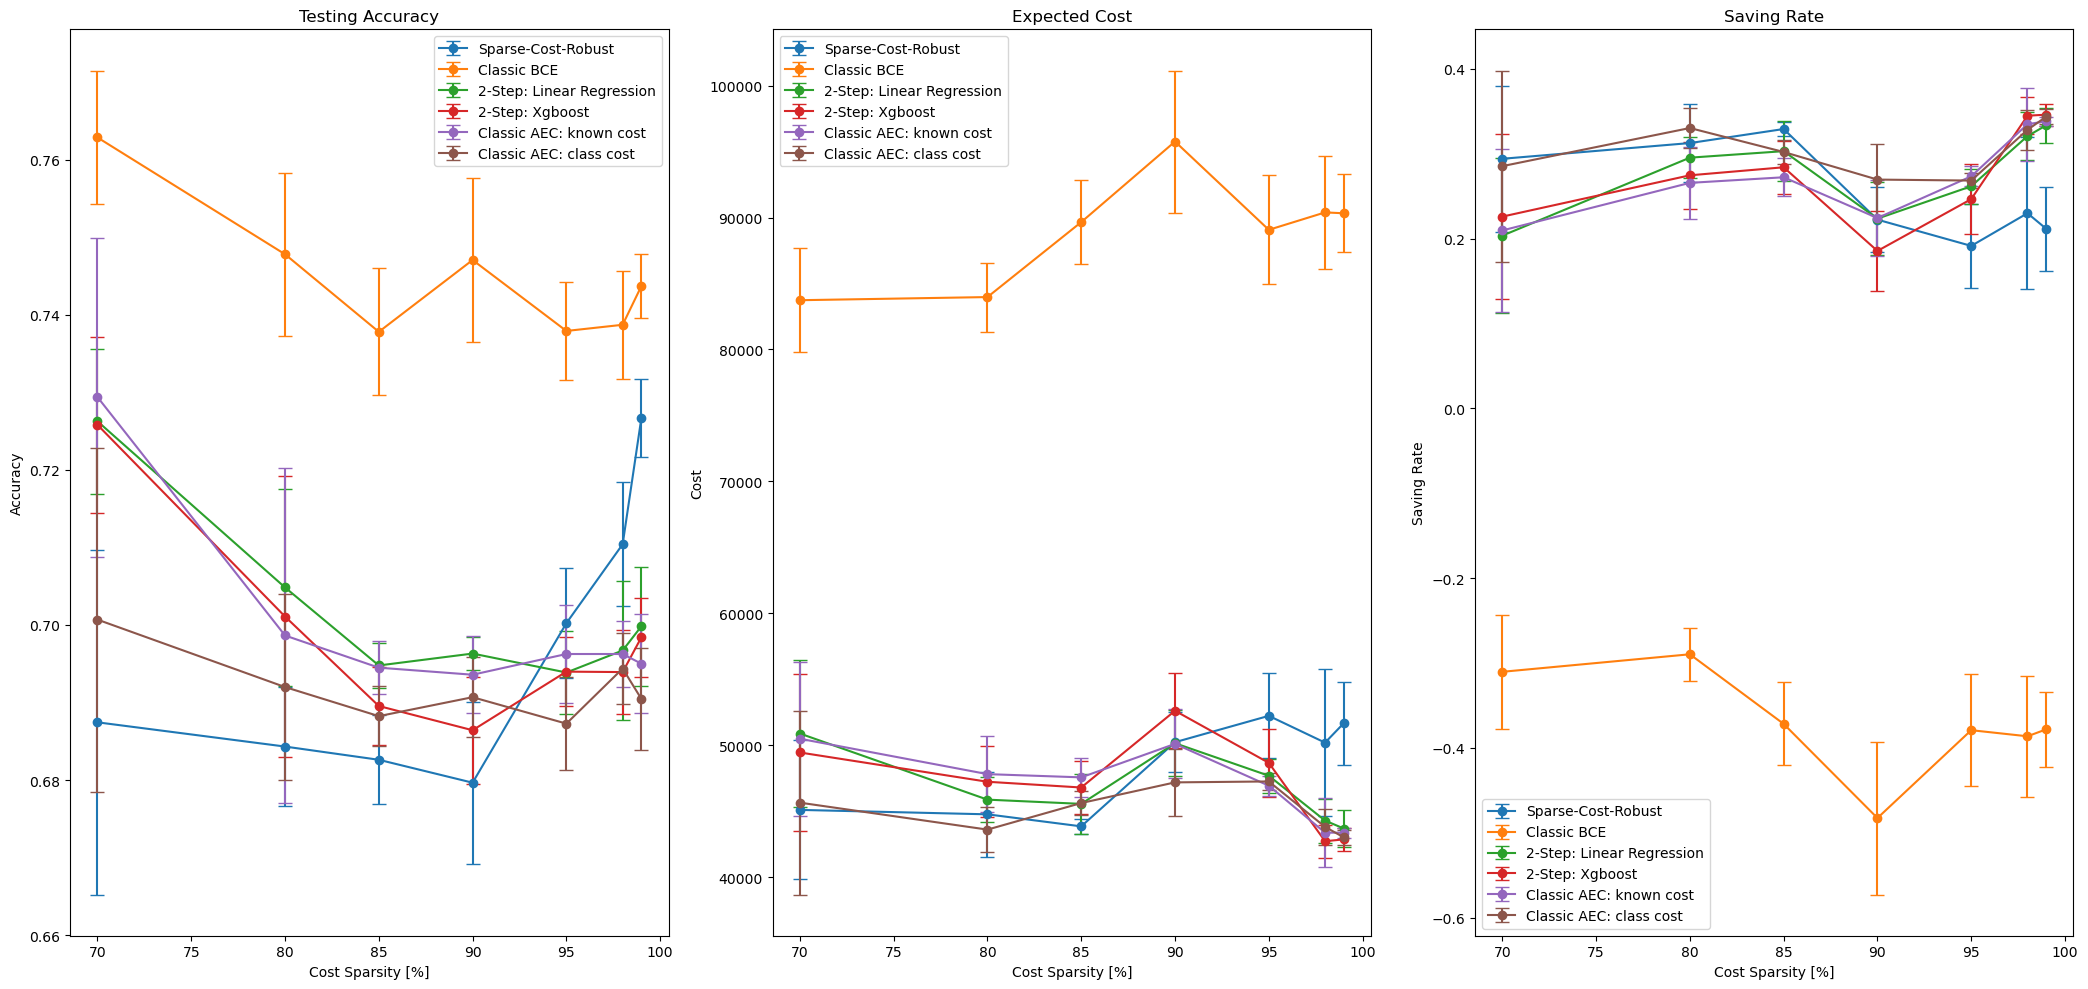

Plain text summary saved to /Users/brunonicoletta/Developer/CSLJupyterNotebook/Results/Kaggle_Telco_Customer_Churn/summary_metrics_by_validation_ratio.txt
LaTeX table saved to /Users/brunonicoletta/Developer/CSLJupyterNotebook/Results/Kaggle_Telco_Customer_Churn/summary_metrics_by_validation_ratio.tex
RMSE summary saved to /Users/brunonicoletta/Developer/CSLJupyterNotebook/Results/Kaggle_Telco_Customer_Churn/summary_rmse_by_validation_ratio.txt
LaTeX RMSE table saved to /Users/brunonicoletta/Developer/CSLJupyterNotebook/Results/Kaggle_Telco_Customer_Churn/summary_rmse_by_validation_ratio.tex


In [ ]:
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def summarize_results(results, n_last=5):
    _, acc_vals = zip(*results["accuracy_log"][-n_last:])
    _, cost_vals = zip(*results["cost_log"][-n_last:])
    _, save_vals = zip(*results["saving_log"][-n_last:])
    return {
        "accuracy": np.mean(acc_vals),
        "expected_cost": np.mean(cost_vals),
        "saving_rate": np.mean(save_vals)
    }

################################################################
######  Experiment parameters -
######  Also possible to use this function instead:
######  set_stantard_experiment_parameters().    [See top of the Notebook]

# Hyperparameters
hyperparameters = {
    'lr' : 1e-3,
    'momentum' : 0.9,
    'batch_size' : 512,
    'num_iterations' : 7000, #13000,
    'weight_decay': 1e-5
}

# Data set selection
data_set = 'Kaggle_Telco_Customer_Churn'   # Choose:  Kaggle_Telco_Customer_Churn, tv_subscription_churn, kdd98, Kaggle_Credit_Card_Fraud, preprocess_bank_marketing
num_repeats = 5


# Ratio
testingRatio = 0.1
#ValidationRatioS = [0.001, 0.002, 0.003, 0.005, 0.01, 0.02, 0.05, 0.1, 0.15, 0.2 ] # Equivalent of the sparsity in this case.  [0.1, 0.05, 0.02, 0.01, 0.005]
#ValidationRatioS = [0.001, 0.002, 0.003, 0.005, 0.01, 0.02, 0.05, 0.08, 0.1, 0.12, 0.15, 0.18, 0.2 ]
#ValidationRatioS = [0.005, 0.01, 0.03, 0.05, 0.08, 0.1, 0.15, 0.2]
ValidationRatioS = [0.3, 0.2, 0.15, 0.1, 0.05, 0.02, 0.01]
#ValidationRatioS = [0.4, 0.3, 0.2, 0.1, 0.05]
#ValidationRatioS = [0.005]

Sparsity = [(1 - v) * 100 for v in ValidationRatioS]

live_plotting = False
print_details = False
print_mainInfo = False
synthetic_cost = False 

noisy = False
training_noise = 0

if noisy:
  print("in noisy")
  training_noise = 0.4 #[0, 0.3, 0.2]

  training_methods = {
      #"AEC_with_LRE": lambda: train_AEC_with_LRE(noisy_train_data_loader, val_data_loader, test_data_loader),
      "Classic_bce": lambda: train_classic_bce(noisy_train_loader_nocost, test_data_loader),
      #"Classic_AEC_known_cost": lambda: train_classic_AEC(noisy_train_data_loader, test_data_loader),
      #"Classic_AEC_combined": lambda: train_classic_AEC(noisy_combined_train_loader, test_data_loader),
      #"Classic_AEC_Only_va_set": lambda: train_classic_AEC(val_data_loader, test_data_loader),
      "Classic_W-BCE_known_cost": lambda: train_classic_WBCE(noisy_train_data_loader, test_data_loader)
    }

else:
  print("Not noisy")
  training_methods = {
      "Sparse-Cost-Robust": lambda: train_AEC_with_LRE(train_data_loader, val_data_loader, test_data_loader),  # train_data_loader , SPB_training_loader
      "Classic BCE": lambda: train_classic_bce(train_loader_nocost, test_data_loader),
      "2-Step: Linear Regression": lambda: train_classic_AEC(train_data_loader_with_logit, test_data_loader),
      "2-Step: Xgboost": lambda: train_classic_AEC(train_data_loader_with_xgboost, test_data_loader),
      "Classic AEC: known cost": lambda: train_classic_AEC(SPB_training_loader, test_data_loader),
      "Classic AEC: class cost": lambda: train_classic_AEC(combined_train_loader, test_data_loader)  #combined
      #"Classic AEC Only val set": lambda: train_classic_AEC(val_data_loader, test_data_loader)
      #"Classic W-BCE known cost": lambda: train_classic_WBCE(train_data_loader, test_data_loader)
  }

accuracy_log = {}
# metric_log = {validationRatio: {"accuracy": [], "expected_cost": [], "saving_rate": []} for validationRatio in ValidationRatioS}
metric_log = {
    validationRatio: {
        method_name: {"accuracy": [], "expected_cost": [], "saving_rate": []}
        for method_name in training_methods
    }
    for validationRatio in ValidationRatioS
}

rmse_log = {
    validationRatio: {
        "Logistic Regression": {"rmse_total": [], "abs_rmse": [], "rel_rmse": []},
        "XGBoost": {"rmse_total": [], "abs_rmse": [], "rel_rmse": []}
    }
    for validationRatio in ValidationRatioS
}


all_results = {}



################################################################
######  Main loop for the experiment

for validationRatio in ValidationRatioS:
  print(f"Validation Ratio: {validationRatio}")

  for k in range(num_repeats):
    print(f"Repeat: {k}")

    ######  Loading and preprocessing the dataset
    if data_set == 'Kaggle_Telco_Customer_Churn':
      X_data, Y_data, amounts, cost_matrix, categorical_variables  = preprocess_telco_customer_churn(eda=False)
    if data_set == 'tv_subscription_churn':
      X_data, Y_data, amounts, cost_matrix, categorical_variables  = preprocess_tv_subscription_churn(eda=False)
    if data_set == 'default_credit_card':
      X_data, Y_data, amounts, cost_matrix, categorical_variables  = preprocess_default_credit_card()
    if data_set == 'kdd98':
      X_data, Y_data, amounts, cost_matrix, categorical_variables  = preprocess_kdd98()
    if data_set == 'Kaggle_Credit_Card_Fraud':
      X_data, Y_data, amounts, cost_matrix, categorical_variables  = preprocess_credit_card_data(fixed_cost=10)
    if data_set == 'preprocess_vub_credit_scoring':
      X_data, Y_data, amounts, cost_matrix, categorical_variables  = preprocess_vub_credit_scoring()
    if data_set == 'preprocess_give_me_some_credit':
      X_data, Y_data, amounts, cost_matrix, categorical_variables  = preprocess_give_me_some_credit()
    if data_set == 'preprocess_bank_marketing':
      X_data, Y_data, amounts, cost_matrix, categorical_variables  = preprocess_bank_marketing()
    if data_set == 'preprocess_kaggle_ieee_fraud':
      X_data, Y_data, amounts, cost_matrix, categorical_variables  = preprocess_kaggle_ieee_fraud()

    (
    X_train, Y_train, cost_matrix_train,
    X_val, Y_val, cost_matrix_val,
    X_test, Y_test, cost_matrix_test,
    X_train_rebalanced, Y_train_rebalanced, cost_matrix_train_rebalanced,
    X_val_balanced, Y_val_balanced, cost_matrix_val_balanced ) = preprocessing_dataset(
        test_ratio = testingRatio,
        val_ratio = validationRatio,
        X_data = X_data,
        Y_data = Y_data,
        amounts = amounts,
        cost_matrix = cost_matrix,
        categorical_variables = categorical_variables)

    ######  Creating the data loader for the experiment
    X_tr_np     = X_train
    Y_tr_np     = Y_train.values
    C_tr_np     = cost_matrix_train

    X_val_np    = X_val
    Y_val_np    = Y_val.values
    C_val_np    = cost_matrix_val

    X_test_np    = X_test
    Y_test_np    = Y_test.values
    C_test_np    = cost_matrix_test

    X_tr_rebalanced_np = X_train_rebalanced
    Y_tr_rebalanced_np = Y_train_rebalanced
    C_tr_rebalanced_np = cost_matrix_train_rebalanced

    X_val_rebalanced_np = X_val_balanced
    Y_val_rebalanced_np = Y_val_balanced
    C_val_rebalanced_np = cost_matrix_val_balanced

    if synthetic_cost:
      print("Synthetic cost")
      C_tr_np = create_synthetic_cost_matrix(X_tr_np, C_tr_np, noise=0.1, clip_negative=True,  booster_params=None)
      C_val_np = create_synthetic_cost_matrix(X_val_np, C_val_np, noise=0.1, clip_negative=True,  booster_params=None)
      C_test_np = create_synthetic_cost_matrix(X_test_np, C_test_np, noise=0.1, clip_negative=True,  booster_params=None)


    # Classic cases
    ds_train = TensorDataset(torch.from_numpy(X_tr_np).float(), torch.from_numpy(Y_tr_np).float(), torch.from_numpy(C_tr_np).float())
    ds_val = TensorDataset(torch.from_numpy(X_val_np).float(), torch.from_numpy(Y_val_np).float(), torch.from_numpy(C_val_np).float())
    ds_test = TensorDataset(torch.from_numpy(X_test_np).float(), torch.from_numpy(Y_test_np).float(), torch.from_numpy(C_test_np).float())
    train_data_loader = DataLoader(ds_train,  batch_size=hyperparameters['batch_size'], shuffle=True)
    #val_data_loader = DataLoader(ds_val,  batch_size=hyperparameters['batch_size'], shuffle=True).
    val_data_loader = DataLoader(ds_val, batch_size=len(ds_val), shuffle=False) # Fixed validation set instead - to avoid variance between mini bacthes (probably need to do the same for training with Stratified Splits)
    test_data_loader = DataLoader(ds_test,  batch_size=hyperparameters['batch_size'], shuffle=False)

    # Special case with rebalanced validation set
    ds_train_rebalanced = TensorDataset(torch.from_numpy(X_tr_rebalanced_np).float(), torch.from_numpy(Y_tr_rebalanced_np).float(), torch.from_numpy(C_tr_rebalanced_np).float())
    ds_val_rebalanced = TensorDataset(torch.from_numpy(X_val_rebalanced_np).float(), torch.from_numpy(Y_val_rebalanced_np).float(), torch.from_numpy(C_val_rebalanced_np).float())
    train_rebalanced_loader = DataLoader(ds_train_rebalanced,  batch_size=hyperparameters['batch_size'], shuffle=True)
    val_rebalanced_loader = DataLoader(ds_val_rebalanced,  batch_size=hyperparameters['batch_size'], shuffle=True)

    # Cost-free training dataset (no cost info)
    ds_train_nocost = TensorDataset(torch.from_numpy(X_tr_np).float(),torch.from_numpy(Y_tr_np).float())
    train_loader_nocost = DataLoader(ds_train_nocost,batch_size=hyperparameters['batch_size'],shuffle=True)

    # Training dataset with cost based on validation set
    mean_cost_matrix = torch.from_numpy(C_val_np).float().mean(dim=0, keepdim=True)  # Mean cost matrix from validation set ; shape: (1, 2, 2)
    mean_cost_tensor = mean_cost_matrix.repeat(X_tr_np.shape[0], 1, 1)  # Fake training set with mean cost repeated; shape: (N_train, 2, 2)
    ds_train_mean_cost = TensorDataset(torch.from_numpy(X_tr_np).float(),torch.from_numpy(Y_tr_np).float(),mean_cost_tensor)

    combined_dataset = torch.utils.data.ConcatDataset([ds_train_mean_cost, ds_val]) # Combining both datasets (training + validation)
    combined_train_loader = DataLoader(combined_dataset,batch_size=hyperparameters['batch_size'], shuffle=True)

    # Adding noise (to validate regular LRE appraoch)
    noisy_train_loader_nocost= get_noisy_dataloader(train_loader_nocost, training_noise)
    noisy_train_data_loader = get_noisy_dataloader_with_cost(train_data_loader, training_noise)
    noisy_combined_train_loader = get_noisy_dataloader_with_cost(combined_train_loader, training_noise)

    # Estimated costs via regression
    C_tr_np_with_logit = estimate_cost_matrix_with_logit(X_val_np, C_val_np, X_tr_np)
    C_tr_np_with_xgboost = estimate_cost_matrix_with_xgboost(X_val_np, C_val_np, X_tr_np)

    ds_train_estimated_cost_with_logit = TensorDataset(torch.from_numpy(X_tr_np).float(),torch.from_numpy(Y_tr_np).float(),torch.from_numpy(C_tr_np_with_logit).float())
    ds_train_estimated_cost_with_xgboost = TensorDataset(torch.from_numpy(X_tr_np).float(),torch.from_numpy(Y_tr_np).float(),torch.from_numpy(C_tr_np_with_xgboost).float())

    train_data_loader_with_logit = DataLoader(ds_train_estimated_cost_with_logit,  batch_size=hyperparameters['batch_size'], shuffle=True)
    train_data_loader_with_xgboost = DataLoader(ds_train_estimated_cost_with_xgboost,  batch_size=hyperparameters['batch_size'], shuffle=True)

    save_dir_matrix_prediction_evaluation = f"/Users/brunonicoletta/Developer/CSLJupyterNotebook/Results/{data_set}/val_{validationRatio}"
    results_matrix_prediction_errors = evaluate_cost_matrix_prediction_errors(C_tr_np, C_tr_np_with_logit, C_tr_np_with_xgboost, save_dir_matrix_prediction_evaluation)

    for model_name in results_matrix_prediction_errors:
      rmse_log[validationRatio][model_name]["rmse_total"].append(results_matrix_prediction_errors[model_name]["rmse_total"])
      rmse_log[validationRatio][model_name]["abs_rmse"].append(results_matrix_prediction_errors[model_name]["abs_rmse"])
      rmse_log[validationRatio][model_name]["rel_rmse"].append(results_matrix_prediction_errors[model_name]["rel_rmse"])

    # StratifiedProportionalBatchSampler
    batch_sampler = StratifiedProportionalBatchSampler(labels=Y_tr_np, batch_size=hyperparameters['batch_size'], shuffle=True)
    SPB_training_loader = DataLoader(ds_train,batch_sampler=batch_sampler)


  ################################################################
  ######  Inner Loop for the repeat
  # for k in range(num_repeats):
  #   print(f"Repeat: {k}")

    for method_name, train_func in training_methods.items():
      print(f"  -> Training method: {method_name}")
      results = train_func()
      all_results[method_name] = results

      # Save training curve
      save_dir = f"/Users/brunonicoletta/Developer/CSLJupyterNotebook/Results/{data_set}/val_{validationRatio}/{method_name}"
      plot_and_save_training_curves(results, validation_ratio=validationRatio, repeat_idx=k, save_dir=save_dir)

      # Summarize results
      summary = summarize_results(results)
      for key in summary:
          metric_log[validationRatio][method_name][key].append(summary[key])

    # Save all-in-one comparison plot
    comparison_path = f"/Users/brunonicoletta/Developer/CSLJupyterNotebook/Results/{data_set}/val_{validationRatio}/Comparison_val{validationRatio}_repeat{k}.png"
    plot_comparison_curves(all_results, save_path=comparison_path, title_prefix=f"Cost Sparsity: {1-validationRatio} | Repeat: {k}")


# Output directory
summary_dir = f"/Users/brunonicoletta/Developer/CSLJupyterNotebook/Results/{data_set}/"
os.makedirs(summary_dir, exist_ok=True)


metrics = ["accuracy", "expected_cost", "saving_rate"]
#metrics = ["accuracy", "expected_cost", "saving_rate", "rmse_total", "rmse_per_cell", "rel_rmse_per_cell"]

titles = {
    "accuracy": "Testing Accuracy",
    "expected_cost": "Expected Cost",
    "saving_rate": "Saving Rate"
}
ylabels = {
    "accuracy": "Accuracy",
    "expected_cost": "Cost",
    "saving_rate": "Saving Rate"
}

plt.figure(figsize=(21, 10))

for i, metric in enumerate(metrics):  # accuracy, expected_cost, saving_rate
    plt.subplot(1, 3, i+1)

    for method_name in training_methods:
        means = [np.mean(metric_log[val][method_name][metric]) for val in ValidationRatioS]
        stds  = [np.std(metric_log[val][method_name][metric]) for val in ValidationRatioS]

        plt.errorbar(Sparsity, means, yerr=stds, label=method_name, fmt='-o', capsize=5)

    plt.title(titles[metric])
    plt.xlabel("Cost Sparsity [%]")
    plt.ylabel(ylabels[metric])
    plt.legend()

plt.tight_layout()

plot_filename = f"{data_set}_metrics_plot.png"
plot_path = os.path.join(summary_dir, plot_filename)
plt.savefig(plot_path, dpi=600)

plt.show()

# Plain text summary 
text_path = os.path.join(summary_dir, "summary_metrics_by_validation_ratio.txt")
with open(text_path, "w") as f_txt:
    for val in ValidationRatioS:
        f_txt.write(f"\n{'='*80}\n")
        f_txt.write(f"Validation Ratio: {val}\n")
        f_txt.write(f"{'-'*80}\n")
        for method_name in training_methods:
            accs = metric_log[val][method_name]["accuracy"]
            costs = metric_log[val][method_name]["expected_cost"]
            saves = metric_log[val][method_name]["saving_rate"]

            acc_mean, acc_std = np.mean(accs), np.std(accs)
            cost_mean, cost_std = np.mean(costs), np.std(costs)
            save_mean, save_std = np.mean(saves), np.std(saves)

            f_txt.write(f"{method_name:<20} | Acc: {acc_mean:.4f} ± {acc_std:.4f}  ||  "
                        f"Cost: {cost_mean:.4f} ± {cost_std:.4f}  ||  "
                        f"Saving: {save_mean:.4f} ± {save_std:.4f}\n")

print(f"Plain text summary saved to {text_path}")

# LaTeX table summary 
latex_path = os.path.join(summary_dir, "summary_metrics_by_validation_ratio.tex")
with open(latex_path, "w") as f_tex:
    f_tex.write("\\begin{tabular}{l l c c c}\n")
    f_tex.write("\\toprule\n")
    f_tex.write("Cost Sparsity & Method & Accuracy & Cost & Saving Rate \\\\\n")
    f_tex.write("\\midrule\n")

    for idx, val in enumerate(ValidationRatioS):
        for method_name in training_methods:
            accs = metric_log[val][method_name]["accuracy"]
            costs = metric_log[val][method_name]["expected_cost"]
            saves = metric_log[val][method_name]["saving_rate"]
            sparsity = Sparsity[idx]

            acc_mean, acc_std = np.mean(accs), np.std(accs)
            cost_mean, cost_std = np.mean(costs), np.std(costs)
            save_mean, save_std = np.mean(saves), np.std(saves)

            f_tex.write(
                f"{sparsity:.0f}\%  & {method_name} & "
                f"{acc_mean:.4f} $\\pm$ {acc_std:.4f} & "
                f"{cost_mean:.4f} $\\pm$ {cost_std:.4f} & "
                f"{save_mean:.4f} $\\pm$ {save_std:.4f} \\\\\n"
            )

        if idx < len(ValidationRatioS) - 1:
            f_tex.write("\\midrule\n")

    f_tex.write("\\bottomrule\n")
    f_tex.write("\\end{tabular}\n")

print(f"LaTeX table saved to {latex_path}")

# RMSE summary: plain text 
rmse_path = os.path.join(summary_dir, "summary_rmse_by_validation_ratio.txt")
with open(rmse_path, "w") as f_rmse:
    for val in ValidationRatioS:
        f_rmse.write(f"\n{'='*80}\n")
        f_rmse.write(f"Validation Ratio: {val}\n")
        f_rmse.write(f"{'-'*80}\n")
        for model_name in rmse_log[val]:
            total_rmse_vals = rmse_log[val][model_name]["rmse_total"]
            abs_rmse_vals = rmse_log[val][model_name]["abs_rmse"]
            rel_rmse_vals = rmse_log[val][model_name]["rel_rmse"]

            total_rmse_mean, total_rmse_std = np.mean(total_rmse_vals), np.std(total_rmse_vals)
            abs_rmse_mean, abs_rmse_std = np.mean(abs_rmse_vals), np.std(abs_rmse_vals)
            rel_rmse_mean, rel_rmse_std = np.mean(rel_rmse_vals), np.std(rel_rmse_vals)

            f_rmse.write(f"{model_name:<20} | RMSE: {total_rmse_mean:.4f} ± {total_rmse_std:.4f}  ||  "
                         f"Abs-RMSE: {abs_rmse_mean:.4f} ± {abs_rmse_std:.4f}  ||  "
                         f"Rel-RMSE: {rel_rmse_mean:.4f} ± {rel_rmse_std:.4f}\n")

print(f"RMSE summary saved to {rmse_path}")

# RMSE summary: LaTeX 
latex_rmse_path = os.path.join(summary_dir, "summary_rmse_by_validation_ratio.tex")
with open(latex_rmse_path, "w") as f_latex_rmse:
    f_latex_rmse.write("\\begin{tabular}{l l c c c}\n")
    f_latex_rmse.write("\\toprule\n")
    f_latex_rmse.write("Cost Sparsity & Model & RMSE & Abs RMSE & Rel RMSE \\\\\n")
    f_latex_rmse.write("\\midrule\n")

    for idx, val in enumerate(ValidationRatioS):
        sparsity = Sparsity[idx]

        for model_name in rmse_log[val]:
            total_rmse_vals = rmse_log[val][model_name]["rmse_total"]
            abs_rmse_vals = rmse_log[val][model_name]["abs_rmse"]
            rel_rmse_vals = rmse_log[val][model_name]["rel_rmse"]

            total_rmse_mean, total_rmse_std = np.mean(total_rmse_vals), np.std(total_rmse_vals)
            abs_rmse_mean, abs_rmse_std = np.mean(abs_rmse_vals), np.std(abs_rmse_vals)
            rel_rmse_mean, rel_rmse_std = np.mean(rel_rmse_vals), np.std(rel_rmse_vals)

            f_latex_rmse.write(
                f"{sparsity:.0f}\\% & {model_name} & "
                f"{total_rmse_mean:.4f} $\\pm$ {total_rmse_std:.4f} & "
                f"{abs_rmse_mean:.4f} $\\pm$ {abs_rmse_std:.4f} & "
                f"{rel_rmse_mean:.4f} $\\pm$ {rel_rmse_std:.4f} \\\\\n"
            )

        if idx < len(ValidationRatioS) - 1:
            f_latex_rmse.write("\\midrule\n")

    f_latex_rmse.write("\\bottomrule\n")
    f_latex_rmse.write("\\end{tabular}\n")

print(f"LaTeX RMSE table saved to {latex_rmse_path}")





## Plotting weights applied

## Plotting for variance noise / proportion / spartisty

In [ ]:
# num_repeats = 5
# # proportions = [0.9,0.95, 0.98, 0.99, 0.995]
# training_noise = [0,0.3, 0.2]
# accuracy_log = {}
# live_plotting = True

# for noise in training_noise:

#     ds_train = TensorDataset(torch.from_numpy(X_tr_np).float(), torch.from_numpy(Y_tr_np).float(), torch.from_numpy(C_tr_np).float())
#     ds_val = TensorDataset(torch.from_numpy(X_val_np).float(), torch.from_numpy(Y_val_np).float(), torch.from_numpy(C_val_np).float())
#     ds_test = TensorDataset(torch.from_numpy(X_test_np).float(), torch.from_numpy(Y_test_np).float(), torch.from_numpy(C_test_np).float())

#     train_data_loader = DataLoader(ds_train,  batch_size=hyperparameters['batch_size'], shuffle=True)
#     val_data_loader = DataLoader(ds_val,  batch_size=hyperparameters['batch_size'], shuffle=False)
#     test_data_loader = DataLoader(ds_test,  batch_size=hyperparameters['batch_size'], shuffle=False)

#     noisy_loader = get_noisy_dataloader(train_data_loader, noise)

#     for k in range(num_repeats):
#         #results = train_classic_bce(noisy_loader, test_data_loader)
#         #results = train_classic_WBCE(train_data_loader, test_data_loader)
#         #results = train_classic_AEC(train_data_loader, test_data_loader)

#         #results = train_BCE_with_LRE(noisy_loader, val_data_loader, test_data_loader)
#         results = train_AEC_with_LRE(noisy_loader, val_data_loader, test_data_loader)

#         accuracy      = results["accuracy"]
#         expected_cost = results["expected_cost"]
#         saving_rate   = results["saving_rate"]

#         if noise in accuracy_log:
#             accuracy_log[noise].append(accuracy)
#         else:
#             accuracy_log[noise] = [accuracy]

# plt.figure(figsize=(10,8))
# for noise in training_noise:
#     accuracies = accuracy_log[noise]
#     plt.scatter([noise] * len(accuracies), accuracies)

# # plot the trend line with error bars that correspond to standard deviation
# accuracies_mean = np.array([np.mean(v) for k,v in sorted(accuracy_log.items())])
# accuracies_std = np.array([np.std(v) for k,v in sorted(accuracy_log.items())])
# plt.errorbar(training_noise, accuracies_mean, yerr=accuracies_std)
# plt.title('Performance on varying class proportions')
# plt.xlabel('proportions')
# plt.ylabel('Accuracy')
# plt.show()



We can see that even at 0.995 proportion of the dominant class in the training data, the model still reaches 90+% accuracy on the balanced test data.